In [1]:
import glob
import os.path as op
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
from sklearn.preprocessing import RobustScaler
from scipy.ndimage import gaussian_filter
from scipy.stats import spearmanr
from sklearn.utils import resample
from statsmodels.robust.robust_linear_model import RLM
import statsmodels.api as sm
import matplotlib.gridspec as gridspec
from generalized_contrastive_PCA import gcPCA

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

In [2]:

def paired_permutation_test(data1, data2, n_permutations=100000):
    # Calculate the observed difference in means
    paired_differences = data1 - data2
    obs_diff = np.mean(paired_differences)
    
    # Permutation test
    perm_diffs = []
    for _ in range(n_permutations):
        # Randomly flip the signs of the paired differences
        signs = np.random.choice([-1, 1], size=len(paired_differences))
        permuted_differences = paired_differences * signs
        perm_diff = np.mean(permuted_differences)
        perm_diffs.append(perm_diff)
    
    # Calculate p-value
    perm_diffs = np.array(perm_diffs)
    p_value = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))
    return obs_diff, p_value

In [3]:
off_color=np.array([228,26,28])/255.0
on_color=np.array([55,126,184])/255.0

### Channel labels

In [4]:
ch_labels=['STN_L1','STN_L2','STN_L3','STN_L4','STN_R1','STN_R2','STN_R3','STN_R4','F3','Fz','F4','C3','C4','Cz']

### Subject labels

In [5]:
data_dir='../../data/preprocessed_data/'
out_path='../../data/derivatives'
data_files=glob.glob(op.join(data_dir, 'dataClean_step1_*_MED_ON.mat'))
subjects = sorted([x.split('/')[-1].split('_')[3] for x in data_files])
print(subjects)

['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's17', 's18']


### Aggregating burst features of the STN and of motor cortex (C3,C4) across all subjects

In [6]:
all_bursts={
    'subject': [],
    'med': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,132)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

for subject in subjects:
    fname=op.join(out_path, 'beta', f'bursts_{subject}.pickle')
    if op.exists(fname):
        print(subject)
        with open(fname,'rb') as file:
            bursts=pickle.load(file)
        stn_c_bursts=np.char.startswith(bursts['channel'].astype(str), 'STN') | (bursts['channel']=='C3') | (bursts['channel']=='C4')
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]
            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key][stn_c_bursts,:]])
            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key][stn_c_bursts]])

s02
s04
s05
s06
s07
s08
s10
s15
s16
s17
s18


### Select bursts corresponding to C3/C4 and all STN contacts

In [57]:
c_idx = (all_bursts['channel']=='C3') | (all_bursts['channel']=='C4')
stn_idx = [ch.startswith('STN') for ch in all_bursts['channel']]

### Plot the beta burst waveform for sensorimotor cortex (C3,C4) Vs STN 

In [58]:
burst_times=all_bursts['waveform_times']*1000   

In [59]:
on_idx=(all_bursts['med']=='ON')
off_idx=(all_bursts['med']=='OFF')
on_c_idx=c_idx & on_idx
off_c_idx=c_idx & off_idx
on_stn_idx=stn_idx & on_idx
off_stn_idx=stn_idx & off_idx

In [60]:
# Scale waveforms within subject
scaled_waveforms = np.zeros_like(all_bursts['waveform'])

for subject in np.unique(all_bursts['subject']):
    subj_idx = (all_bursts['subject'] == subject)
    scaler = RobustScaler().fit(all_bursts['waveform'][subj_idx])
    scaled_waveforms[subj_idx, :] = scaler.transform(all_bursts['waveform'][subj_idx])

In [61]:
c_gcpca_model = gcPCA(method='v4',normalize_flag=False)
c_gcpca_model.fit(scaled_waveforms[off_c_idx, :], scaled_waveforms[on_c_idx, :])

stn_gcpca_model = gcPCA(method='v4',normalize_flag=False)
stn_gcpca_model.fit(scaled_waveforms[off_stn_idx, :], scaled_waveforms[on_stn_idx, :])

c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


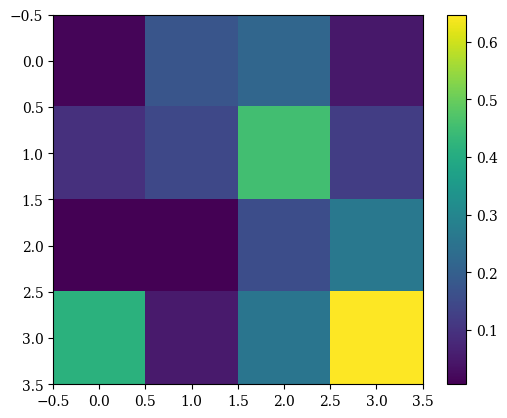

In [62]:
n_pcs_to_show=4
corr_mat=np.zeros((n_pcs_to_show,n_pcs_to_show))
indices=[0,1,-2,-1]
for i in range(n_pcs_to_show):
    for j in range(n_pcs_to_show):
        spearman_coefficient, spearman_p_value = spearmanr(c_gcpca_model.loadings_[:,indices[i]], stn_gcpca_model.loadings_[:,indices[j]])
        corr_mat[i,j]=np.abs(spearman_coefficient)
h=plt.imshow(corr_mat)
plt.colorbar(h)

In [63]:
gcpca_model = gcPCA(method='v4',normalize_flag=False)

In [64]:
# Now, fit the models on the pooled, subject-scaled data
on_bursts = scaled_waveforms[on_idx, :]
off_bursts = scaled_waveforms[off_idx, :]
gcpca_model.fit(off_bursts, on_bursts)

# Project all bursts into PC space
all_scores = np.zeros((all_bursts['waveform'].shape[0], gcpca_model.loadings_.shape[1]))
all_scores[off_idx, :] = gcpca_model.Ra_scores_
all_scores[on_idx, :] = gcpca_model.Rb_scores_


In [81]:
def plot_gcpca(b_idx, lim=0.1):

    on_b_idx=b_idx & on_idx
    off_b_idx=b_idx & off_idx

    # Create a figure with constrained layout
    fig = plt.figure(figsize=(15, 6), constrained_layout=True)
    gs = gridspec.GridSpec(2, 5, figure=fig)
    
    # Helper to force square axes
    def make_square(ax):
        ax.set_box_aspect(1)  # This ensures the subplot is a square (1:1 height:width)
    
    n_q=3
    col_r = plt.cm.cool(np.linspace(0, 1, num=n_q))
    step=100/n_q
    
    q_bins = np.percentile(all_scores[b_idx,0], np.arange(0,100+step,step))
    # plot loadings
    ax1 = fig.add_subplot(gs[0, 0])
    for q in range(n_q):
        q_idx = b_idx & (all_scores[:,0]>=q_bins[q]) & (all_scores[:,0]<=q_bins[q+1])
        q_waveform = np.mean(all_bursts['waveform'][q_idx,:],axis=0)
        ax1.plot(burst_times, q_waveform, color=col_r[q,:], label=f'T{q+1}')
    ax1.set_xlabel('Burst time (ms)')
    ax1.set_ylabel('Amplitude (µV)')
    plt.legend(loc='lower right')
    make_square(ax1)
    
    q_bins = np.percentile(all_scores[b_idx,1], np.arange(0,100+step,step))
    # plot loadings
    ax2 = fig.add_subplot(gs[0, 1])
    for q in range(n_q):
        q_idx = b_idx & (all_scores[:,1]>=q_bins[q]) & (all_scores[:,1]<=q_bins[q+1])
        q_waveform = np.mean(all_bursts['waveform'][q_idx,:],axis=0)
        ax2.plot(burst_times, q_waveform, color=col_r[q,:], label=f'T{q+1}')
    ax2.set_xlabel('Burst time (ms)')
    ax2.set_ylabel('Amplitude (µV)')
    plt.legend(loc='lower right')
    make_square(ax2)
    
    all_radii=np.sqrt(all_scores[:,0]**2 + all_scores[:,1]**2)
    off_rad_bins = np.percentile(all_radii[b_idx], np.arange(0,100+step,step))
    # plot condition A scores and values
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.scatter(all_scores[off_b_idx, 0], all_scores[off_b_idx, 1],c='b',s=4,alpha=.5,label='off')
    for i in range(n_q):
        circle = patches.Circle((0, 0), off_rad_bins[i+1], edgecolor='k', facecolor='none', linestyle='--', linewidth=2)
        ax3.add_patch(circle)
    ax3.set_xlabel('gcPC1', fontsize=16)
    ax3.set_ylabel('gcPC2', fontsize=16)
    ax3.set_xlim([-lim,lim])
    ax3.set_ylim([-lim,lim])
    # plt.legend()
    make_square(ax3)

    # plot condition A scores and values
    ax4 = fig.add_subplot(gs[0, 3])
    ax4.scatter(all_scores[on_b_idx, 0], all_scores[on_b_idx, 1],c='r',s=4,alpha=.5,label='on')
    for i in range(n_q):
        circle = patches.Circle((0, 0), off_rad_bins[i+1], edgecolor='k', facecolor='none', linestyle='--', linewidth=2)
        ax4.add_patch(circle)
    ax4.set_xlabel('gcPC1', fontsize=16)
    # ax4.set_ylabel('gcPC2', fontsize=16)
    ax4.set_xlim([-lim,lim])
    ax4.set_ylim([-lim,lim])
    # plt.legend()
    make_square(ax4)

    ax5 = fig.add_subplot(gs[0,4])
    off_radii=np.sqrt(all_scores[off_b_idx, 0]**2 + all_scores[off_b_idx, 1]**2)
    on_radii=np.sqrt(all_scores[on_b_idx, 0]**2 + all_scores[on_b_idx, 1]**2)
    ax5.hist(off_radii,500,color='b',alpha=0.5,label='off',density=True)
    ax5.hist(on_radii,500,color='r',alpha=0.5,label='on',density=True)
    ax5.set_xlim([0,lim])
    for i in range(n_q):
        ax5.axvline(off_rad_bins[i+1],color='k',linestyle='--')
    plt.legend()
    make_square(ax5)
    
    q_bins = np.percentile(all_scores[b_idx,-1], np.arange(0,100+step,step))
    # plot loadings
    ax6 = fig.add_subplot(gs[1, 0])
    for q in range(n_q):
        q_idx = b_idx & (all_scores[:,-1]>=q_bins[q]) & (all_scores[:,-1]<=q_bins[q+1])
        q_waveform = np.mean(all_bursts['waveform'][q_idx,:],axis=0)
        ax6.plot(burst_times, q_waveform, color=col_r[q,:], label=f'T{q+1}')
    ax6.set_xlabel('Burst time (ms)')
    ax6.set_ylabel('Amplitude (µV)')
    plt.legend(loc='lower right')
    make_square(ax6)
    
    q_bins = np.percentile(all_scores[b_idx,-2], np.arange(0,100+step,step))
    # plot loadings
    ax7 = fig.add_subplot(gs[1, 1])
    for q in range(n_q):
        q_idx = b_idx & (all_scores[:,-2]>=q_bins[q]) & (all_scores[:,-2]<=q_bins[q+1])
        q_waveform = np.mean(all_bursts['waveform'][q_idx,:],axis=0)
        ax7.plot(burst_times, q_waveform, color=col_r[q,:], label=f'T{q+1}')
    ax7.set_xlabel('Burst time (ms)')
    ax7.set_ylabel('Amplitude (µV)')
    plt.legend(loc='lower right')
    make_square(ax7)
    
    all_radii=np.sqrt(all_scores[:,-1]**2 + all_scores[:,-2]**2)
    on_rad_bins = np.percentile(all_radii[b_idx], np.arange(0,100+step,step))
    ax8 = fig.add_subplot(gs[1, 2])
    ax8.scatter(all_scores[off_b_idx, -1], all_scores[off_b_idx, -2],c='b',s=4,alpha=.5,label='off')
    for i in range(n_q):
        circle = patches.Circle((0, 0), on_rad_bins[i+1], edgecolor='k', facecolor='none', linestyle='--', linewidth=2)
        ax8.add_patch(circle)
    ax8.set_xlabel('gcPC(last)', fontsize=16)
    ax8.set_ylabel('gcPC(last-1)', fontsize=16)
    ax8.set_xlim([-lim,lim])
    ax8.set_ylim([-lim,lim])
    # plt.legend()
    make_square(ax8)

    ax9 = fig.add_subplot(gs[1, 3])
    ax9.scatter(all_scores[on_b_idx, -1], all_scores[on_b_idx, -2],c='r',s=4,alpha=.5,label='on')
    for i in range(n_q):
        circle = patches.Circle((0, 0), on_rad_bins[i+1], edgecolor='k', facecolor='none', linestyle='--', linewidth=2)
        ax9.add_patch(circle)
    ax9.set_xlabel('gcPC(last)', fontsize=16)
    # ax9.set_ylabel('gcPC(last-1)', fontsize=16)
    ax9.set_xlim([-lim,lim])
    ax9.set_ylim([-lim,lim])
    # plt.legend()
    make_square(ax9)

    ax10 = fig.add_subplot(gs[1,4])
    off_radii=np.sqrt(all_scores[off_b_idx, -1]**2 + all_scores[off_b_idx, -2]**2)
    on_radii=np.sqrt(all_scores[on_b_idx, -1]**2 + all_scores[on_b_idx, -2]**2)
    ax10.hist(off_radii,500,color='b',alpha=0.5,label='off',density=True)
    ax10.hist(on_radii,500,color='r',alpha=0.5,label='on',density=True)
    ax10.set_xlim([0,lim])
    for i in range(n_q):
        ax10.axvline(on_rad_bins[i+1],color='k',linestyle='--')
    plt.legend()
    make_square(ax10)
    
    plt.show()

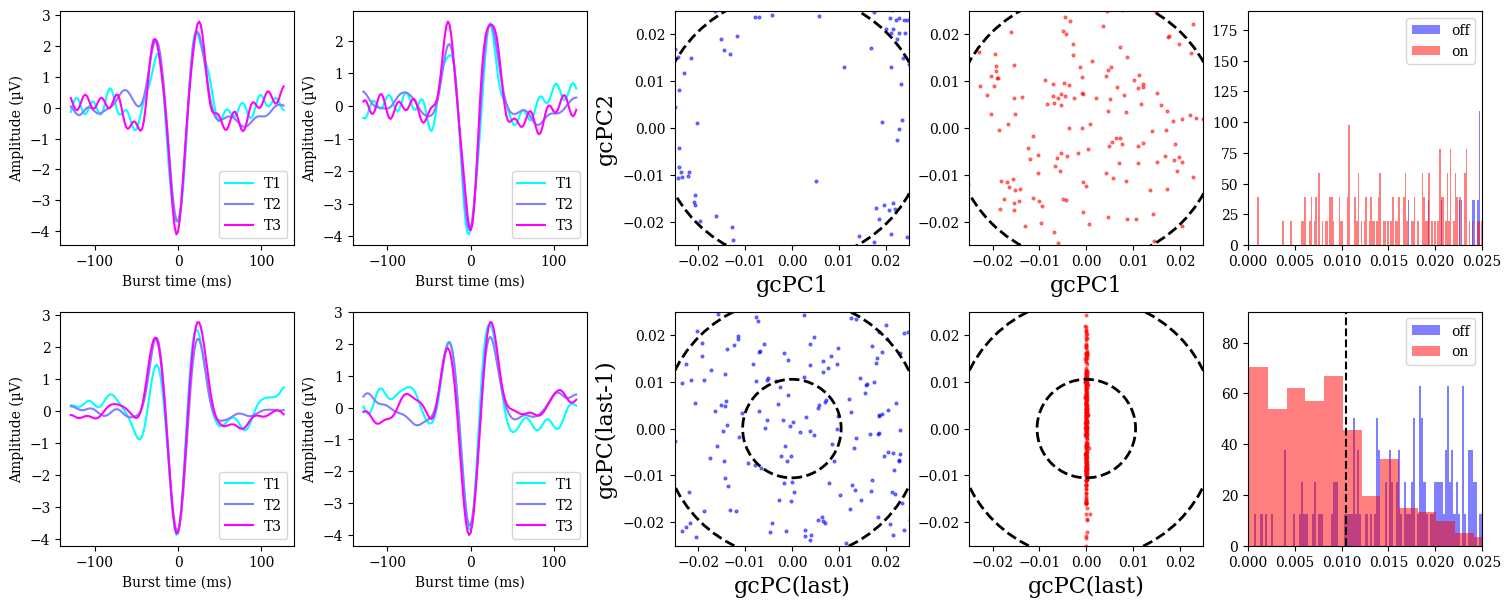

In [82]:
plot_gcpca(c_idx, lim=0.025)

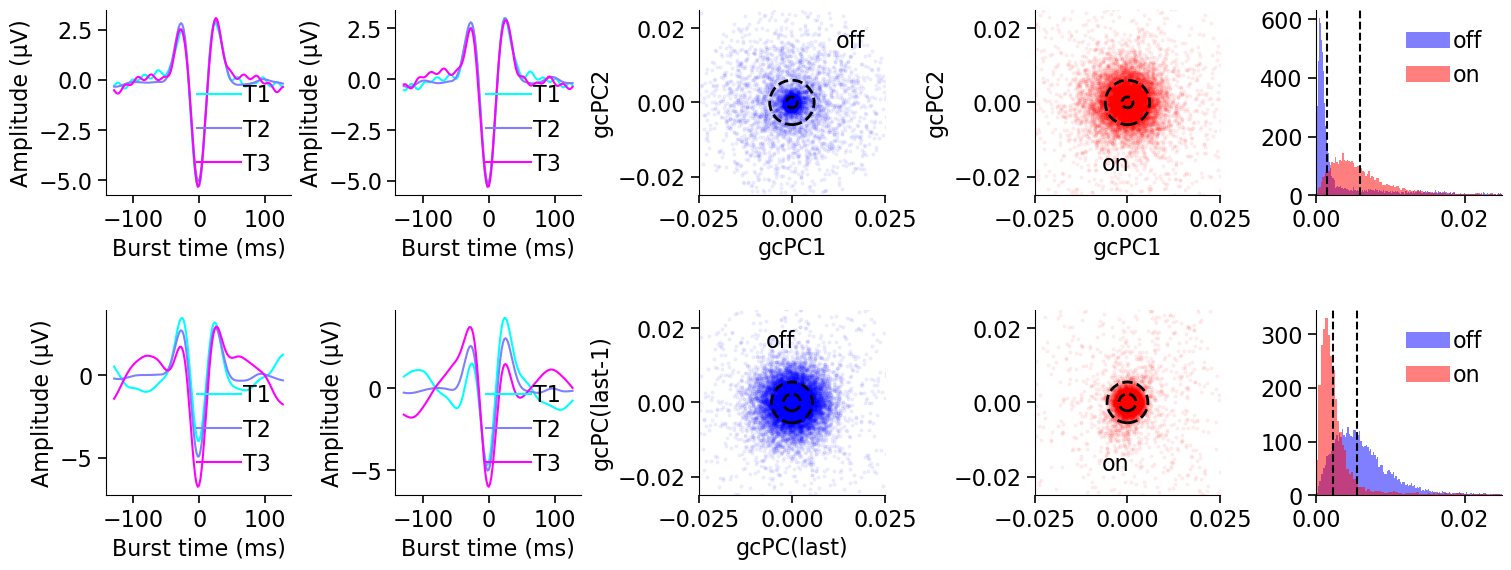

In [181]:
plot_gcpca(stn_idx, lim=0.025)

### Plot burst rates and waveforms modulated by a specific principal component (PC) across different tertiles and medication conditions.

In [182]:
def plot_radius_burst_rate(b_idx, pc_idx1, pc_idx2, n_electrodes=1):
    trial_dur = 4
    radius = np.sqrt(all_scores[:, pc_idx1]**2 + all_scores[:, pc_idx2]**2)
    
    n_q = 3
    step = 100 / n_q

    q_bins = np.percentile(radius[b_idx], np.arange(0, 100 + step, step))
    
    time_bin_size = .05
    time_bins = np.arange(0, trial_dur + time_bin_size, time_bin_size)

    q_rates_smoothed = {q: {'ON': [], 'OFF': []} for q in range(n_q)}
    q_rates_unsmoothed = {q: {'ON': [], 'OFF': []} for q in range(n_q)}
    
    for subject in subjects:
        subj_idx = b_idx & (all_bursts['subject'] == subject)
        for q in range(n_q):
            q_idx = (radius >= q_bins[q]) & (radius <= q_bins[q+1])

            for med in ['ON', 'OFF']:
                med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med'] == med)])
                unsmoothed_rate, _ = np.histogram(all_bursts['peak_time'][subj_idx & (all_bursts['med'] == med) & q_idx], bins=time_bins)
                unsmoothed_rate = (unsmoothed_rate / time_bin_size) / len(med_trials) / n_electrodes
                q_rates_unsmoothed[q][med].append(unsmoothed_rate)

                smoothed_rate = gaussian_filter(unsmoothed_rate, sigma=2.5)
                q_rates_smoothed[q][med].append(smoothed_rate)

    time_bins = time_bins[:-1]
    idx = np.where((time_bins >= 1) & (time_bins <= (trial_dur - 1)))[0]
    time_bins = time_bins[idx]
    
    perm_results = []
    avg_rates = {q: {'ON': [], 'OFF': []} for q in range(n_q)}
    for q in q_rates_unsmoothed:
        for med in q_rates_unsmoothed[q]:
            q_rates_unsmoothed[q][med] = np.vstack(q_rates_unsmoothed[q][med])[:, idx]
            q_rates_smoothed[q][med] = np.vstack(q_rates_smoothed[q][med])[:, idx]
            avg_rates[q][med] = np.mean(q_rates_unsmoothed[q][med], axis=1)

        diff, p_value = paired_permutation_test(avg_rates[q]['ON'], avg_rates[q]['OFF'])
        p_value = np.min([1.0, p_value * n_q])
        perm_results.append(p_value)
        m_on = np.mean(avg_rates[q]['ON'])
        sd_on = np.std(avg_rates[q]['ON'])
        m_off = np.mean(avg_rates[q]['OFF'])
        sd_off = np.std(avg_rates[q]['OFF'])
        print(f"Radius T{q+1}: OFF: M={m_off:.3f}, SD={sd_off:.3f}, ON: M={m_on:.3f}, SD={sd_on:.3f}, p-value={p_value:.3f}")

    all_rates = []
    for q in range(n_q):
        for med in ['ON', 'OFF']:
            all_rates.append(np.mean(q_rates_smoothed[q][med], axis=0))
    all_rates = np.concatenate(all_rates)
    y_max = np.max(all_rates)
    y_pad = 0.3 * y_max
    burst_rate_ylim = [0, y_max + y_pad]

    plt.figure(figsize=(16, 18)) 
    
    plt.rcParams.update({
        'font.size': 16,
        'axes.spines.right': False,
        'axes.spines.top': False,
        'xtick.major.size': 6,
        'xtick.major.width': 1.2,
        'ytick.major.size': 6,
        'ytick.major.width': 1.2,
        'legend.frameon': False,
        'legend.handletextpad': 0.1,
        'svg.fonttype': 'none',
        'text.usetex': False
    })
    col_r = plt.cm.cool(np.linspace(0, 1, num=n_q))

    labels=['a','b']
    for m_idx, (med,label) in enumerate(zip(['OFF', 'ON'],labels)):
        ax = plt.subplot(4, 2, m_idx + 1)
        for q in range(n_q):
            burst_idx = b_idx & (all_bursts['med'] == med) & (radius >= q_bins[q]) & (radius <= q_bins[q+1])
            m_waveform = np.mean(all_bursts['waveform'][burst_idx, :], axis=0)
            ax.plot(burst_times, m_waveform, color=col_r[q, :], linewidth=2, label=f'T{q+1}')
        ax.set_xlabel('Burst time (ms)')
        ax.set_ylabel('Amplitude (µV)')
        ax.set_ylim([-12,6])
        plt.legend()

    labels=['c','d']
    for m_idx, (med,label) in enumerate(zip(['OFF', 'ON'],labels)):
        ax = plt.subplot(4, 2, m_idx + 3)
        for q in range(n_q):
            m_rate = np.mean(q_rates_smoothed[q][med], axis=0)
            se_rate = np.std(q_rates_smoothed[q][med], axis=0) / np.sqrt(q_rates_smoothed[q][med].shape[0])
            ax.plot(time_bins, m_rate, label=f"T{q+1}", color=col_r[q, :])
            ax.fill_between(time_bins, m_rate - se_rate, m_rate + se_rate, alpha=.2, color=col_r[q, :])
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Burst rate') 
        ax.set_ylim(burst_rate_ylim)
        plt.legend()

    labels=['e','f','g']
    for q in range(n_q):
        ax = plt.subplot(4, n_q, 7 + q)
        data_on = avg_rates[q]['ON']
        data_off = avg_rates[q]['OFF']

        bp = ax.boxplot([data_on, data_off], patch_artist=True, vert=False, widths=0.1,
                        positions=[.5, 1])
        for patch in bp['boxes']:
            patch.set_facecolor(col_r[q, :])
            patch.set_alpha(0.4)

        for median in bp['medians']:
            median.set_color('black')
            median.set_linewidth(1.5)

        vp = ax.violinplot([data_on, data_off], points=500, 
                           showmeans=False, showextrema=False, showmedians=False, vert=False)
        for idx, b in enumerate(vp['bodies']):
            b.set_alpha(0.5)
            b.set_facecolor(col_r[q,:])
            center = np.mean(b.get_paths()[0].vertices[:, 1])
            shift = 0.5+(idx*0.5)
            b.get_paths()[0].vertices[:, 1] = np.clip(b.get_paths()[0].vertices[:, 1] - center + shift, shift, shift + 0.5)

        ys=[]
        for idx, data in enumerate([data_on, data_off]):
            jittered_y = np.full(len(data), .5+(idx*.5)) + np.random.uniform(-0.05, 0.05, len(data))
            ax.scatter(data, jittered_y, s=10, color=col_r[q,:], alpha=0.7, edgecolor='black')
            ys.append(jittered_y)
        ys = np.array(ys)
        for s_idx in range(data_on.shape[0]):
            ax.plot([data_on[s_idx], data_off[s_idx]], [ys[0, s_idx], ys[1, s_idx]], 'k')

        ax.set_xlim(min(min(data_on), min(data_off)) - 0.1, max(max(data_on), max(data_off)) + 0.1)
        ax.set_yticks([.5, 1])
        ax.set_yticklabels(['ON', 'OFF'])
        ax.set_ylim([.4,1.3])
        ax.set_xlabel('Burst rate (Hz)')        
        
    plt.tight_layout()



def plot_pc_burst_rate(pc_idx, b_idx, n_electrodes=1):
    trial_dur=4
    n_q=3
    step=100/n_q
    q_bins = np.percentile(all_scores[b_idx,pc_idx], np.arange(0,100+step,step))
    
    time_bin_size = .05
    time_bins = np.arange(0, trial_dur + time_bin_size, time_bin_size)

    q_rates_smoothed = {}
    q_rates_unsmoothed = {}
    for q in range(n_q):
        q_rates_smoothed[q] = {'ON': [], 'OFF': []}
        q_rates_unsmoothed[q] = {'ON': [], 'OFF': []}
    for subject in subjects:
        subj_idx = b_idx & (all_bursts['subject'] == subject)
        for q in range(n_q):
            q_idx = (all_scores[:,pc_idx] >= q_bins[q]) & (all_scores[:,pc_idx] <= q_bins[q+1])

            for med in ['ON', 'OFF'] :
                med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med']==med)])
                unsmoothed_rate, _ = np.histogram(all_bursts['peak_time'][subj_idx & (all_bursts['med'] == med) & q_idx], bins=time_bins)
                unsmoothed_rate = (unsmoothed_rate / time_bin_size) / len(med_trials) / n_electrodes
                q_rates_unsmoothed[q][med].append(unsmoothed_rate)

                smoothed_rate = gaussian_filter(unsmoothed_rate, sigma=2.5)
                q_rates_smoothed[q][med].append(smoothed_rate)

    time_bins = time_bins[:-1]
    idx = np.where((time_bins >= 1) & (time_bins <= (trial_dur - 1)))[0]
    time_bins = time_bins[idx]
    
    perm_results = []
    avg_rates = {q: {'ON': [], 'OFF': []} for q in range(n_q)}
    for q in q_rates_unsmoothed:
        for med in q_rates_unsmoothed[q]:
            q_rates_unsmoothed[q][med] = np.vstack(q_rates_unsmoothed[q][med])[:, idx]
            q_rates_smoothed[q][med] = np.vstack(q_rates_smoothed[q][med])[:, idx]
            avg_rates[q][med] = np.mean(q_rates_unsmoothed[q][med], axis=1)

        diff, p_value = paired_permutation_test(avg_rates[q]['ON'], avg_rates[q]['OFF'])
        p_value = np.min([1.0, p_value * n_q])
        perm_results.append(p_value)
        m_on=np.mean(avg_rates[q]['ON'])
        sd_on=np.std(avg_rates[q]['ON'])
        m_off=np.mean(avg_rates[q]['OFF'])
        sd_off=np.std(avg_rates[q]['OFF'])
        print(f"PC{pc_idx+1} T{q+1}: OFF: M={m_off:.3f}, SD={sd_off:.3f},  ON: M={m_on:.3f}, SD={sd_on:.3f}, p-value = {p_value:.3f}")

    # Compute global y-limits for burst rate plots
    all_rates = []
    for q in range(n_q):
        for med in ['ON', 'OFF']:
            all_rates.append(np.mean(q_rates_smoothed[q][med], axis=0))
    all_rates = np.concatenate(all_rates)
    y_max = np.max(all_rates)
    y_pad = 0.3 * y_max
    burst_rate_ylim = [0, y_max + y_pad]

    plt.figure(figsize=(16, 18)) 
    
    plt.rcParams.update({
        'font.size': 16,
        'axes.spines.right': False,
        'axes.spines.top': False,
        'xtick.major.size': 6,
        'xtick.major.width': 1.2,
        'ytick.major.size': 6,
        'ytick.major.width': 1.2,
        'legend.frameon': False,
        'legend.handletextpad': 0.1,
        'svg.fonttype': 'none',
        'text.usetex': False
    })
    col_r = plt.cm.cool(np.linspace(0, 1, num=n_q))

    labels=['a','b']
    for m_idx, (med,label) in enumerate(zip(['OFF', 'ON'],labels)):
        ax = plt.subplot(4, 2, m_idx + 1)
        for q in range(n_q):
            burst_idx = b_idx & (all_bursts['med']==med) & (all_scores[:,pc_idx] >= q_bins[q]) & (all_scores[:,pc_idx] <= q_bins[q+1])
            m_waveform=np.mean(all_bursts['waveform'][burst_idx,:],axis=0)
            ax.plot(burst_times, m_waveform, color=col_r[q,:], linewidth=2, label=f'T{q+1}')
        ax.set_xlabel('Burst time (ms)')
        ax.set_ylabel('Amplitude (µV)')
        ax.set_ylim([-12,6])
        plt.legend()

    labels=['c','d']
    for m_idx, (med,label) in enumerate(zip(['OFF', 'ON'],labels)):
        ax = plt.subplot(4, 2, m_idx + 3)
        for q in range(n_q):
            m_rate = np.mean(q_rates_smoothed[q][med], axis=0)
            se_rate = np.std(q_rates_smoothed[q][med], axis=0) / np.sqrt(q_rates_smoothed[q][med].shape[0])
            ax.plot(time_bins, m_rate, label=f"T{q+1}", color=col_r[q, :])
            ax.fill_between(time_bins, m_rate - se_rate, m_rate + se_rate, alpha=.2, color=col_r[q, :])
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Burst rate') 
        ax.set_ylim(burst_rate_ylim)
        plt.legend()

    labels=['e','f','g']
    for q in range(n_q):
        ax = plt.subplot(4, n_q, 7 + q)
        data_on = avg_rates[q]['ON']
        data_off = avg_rates[q]['OFF']

        bp = ax.boxplot([data_on, data_off], patch_artist=True, vert=False, widths=0.1,
                        positions=[.5, 1])
        for patch in bp['boxes']:
            patch.set_facecolor(col_r[q, :])
            patch.set_alpha(0.4)

        for median in bp['medians']:
            median.set_color('black')
            median.set_linewidth(1.5)

        vp = ax.violinplot([data_on, data_off], points=500, 
                           showmeans=False, showextrema=False, showmedians=False, vert=False)
        for idx, b in enumerate(vp['bodies']):
            b.set_alpha(0.5)
            b.set_facecolor(col_r[q,:])
            center = np.mean(b.get_paths()[0].vertices[:, 1])
            shift = 0.5+(idx*0.5)
            b.get_paths()[0].vertices[:, 1] = np.clip(b.get_paths()[0].vertices[:, 1] - center + shift, shift, shift + 0.5)

        ys=[]
        for idx, data in enumerate([data_on, data_off]):
            jittered_y = np.full(len(data), .5+(idx*.5)) + np.random.uniform(-0.05, 0.05, len(data))
            ax.scatter(data, jittered_y, s=10, color=col_r[q,:], alpha=0.7, edgecolor='black')
            ys.append(jittered_y)
        ys=np.array(ys)
        for s_idx in range(data_on.shape[0]):
            ax.plot([data_on[s_idx], data_off[s_idx]], [ys[0,s_idx], ys[1,s_idx]],'k')

        ax.set_xlim(min(min(data_on), min(data_off)) - 0.1, max(max(data_on), max(data_off)) + 0.1)
        ax.set_yticks([.5, 1])
        ax.set_yticklabels(['ON', 'OFF'])
        ax.set_ylim([.4,1.3])
        ax.set_xlabel('Burst rate (Hz)')        
        
    plt.tight_layout()


PC1 T1: OFF: M=0.932, SD=0.719,  ON: M=1.577, SD=0.335, p-value = 0.032
PC1 T2: OFF: M=1.887, SD=1.264,  ON: M=0.460, SD=0.192, p-value = 0.020
PC1 T3: OFF: M=0.952, SD=0.770,  ON: M=1.557, SD=0.350, p-value = 0.036


/tmp/ipykernel_16129/3723651248.py:287: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


PC2 T1: OFF: M=0.963, SD=0.740,  ON: M=1.545, SD=0.304, p-value = 0.057
PC2 T2: OFF: M=1.820, SD=1.281,  ON: M=0.508, SD=0.267, p-value = 0.026
PC2 T3: OFF: M=0.988, SD=0.773,  ON: M=1.541, SD=0.315, p-value = 0.030


/tmp/ipykernel_16129/3723651248.py:287: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


PC-1 T1: OFF: M=1.597, SD=0.364,  ON: M=0.938, SD=0.467, p-value = 0.006
PC-1 T2: OFF: M=0.719, SD=0.293,  ON: M=1.714, SD=0.704, p-value = 0.003
PC-1 T3: OFF: M=1.455, SD=0.335,  ON: M=0.941, SD=0.371, p-value = 0.062


/tmp/ipykernel_16129/3723651248.py:287: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


PC0 T1: OFF: M=1.542, SD=0.260,  ON: M=0.918, SD=0.377, p-value = 0.002
PC0 T2: OFF: M=0.743, SD=0.230,  ON: M=1.739, SD=0.731, p-value = 0.006
PC0 T3: OFF: M=1.486, SD=0.275,  ON: M=0.936, SD=0.472, p-value = 0.010


/tmp/ipykernel_16129/3723651248.py:287: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


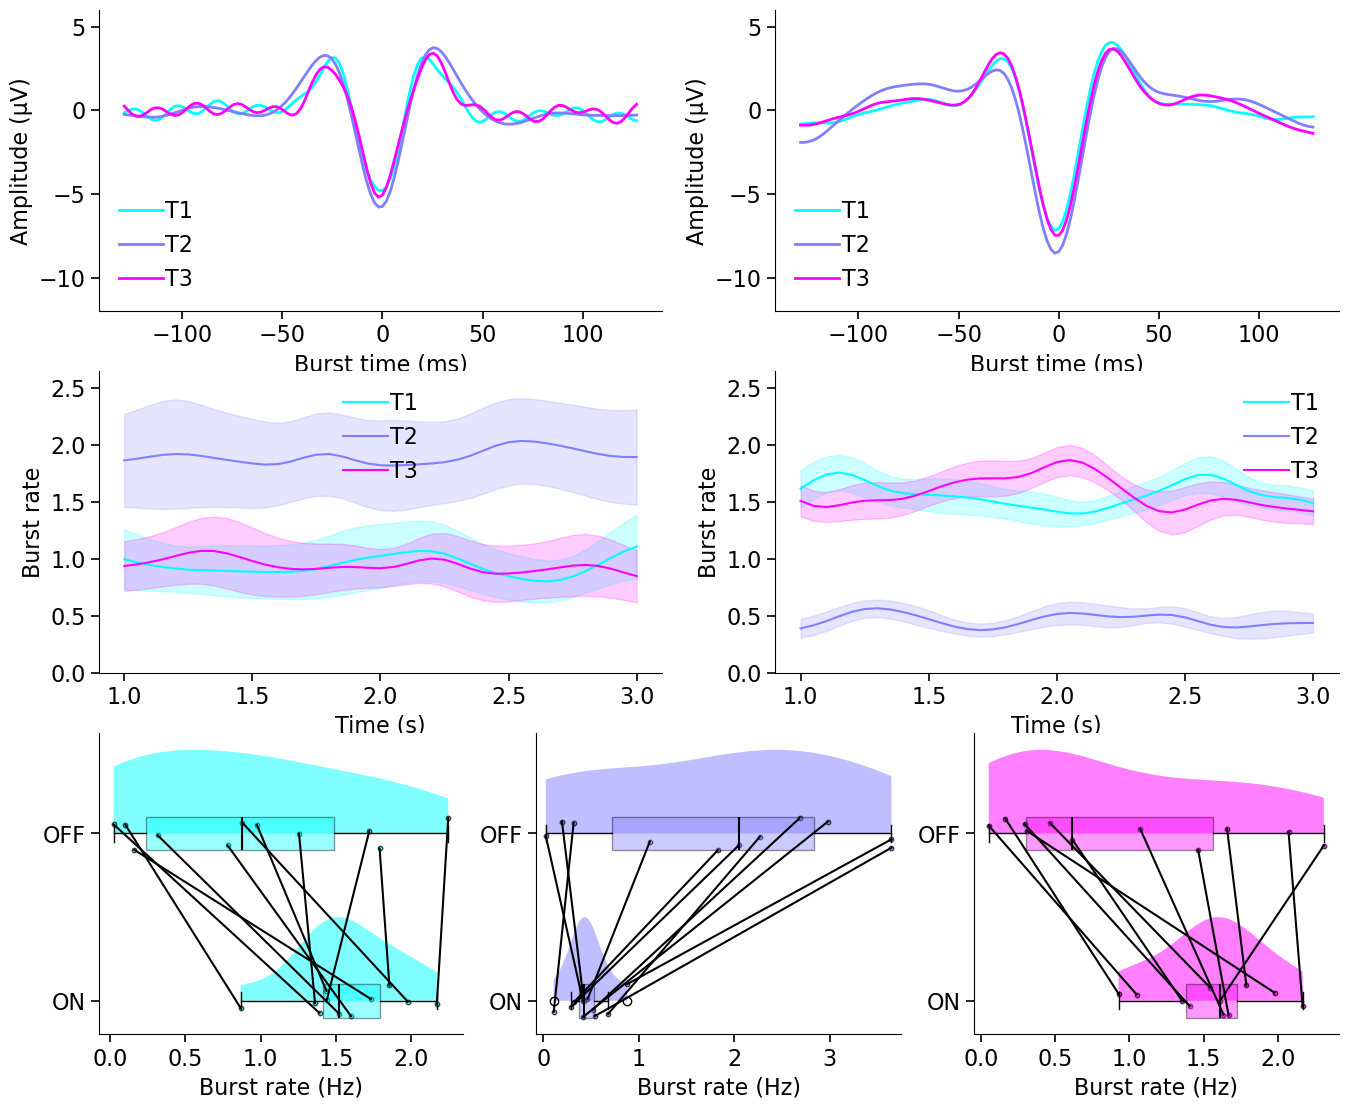

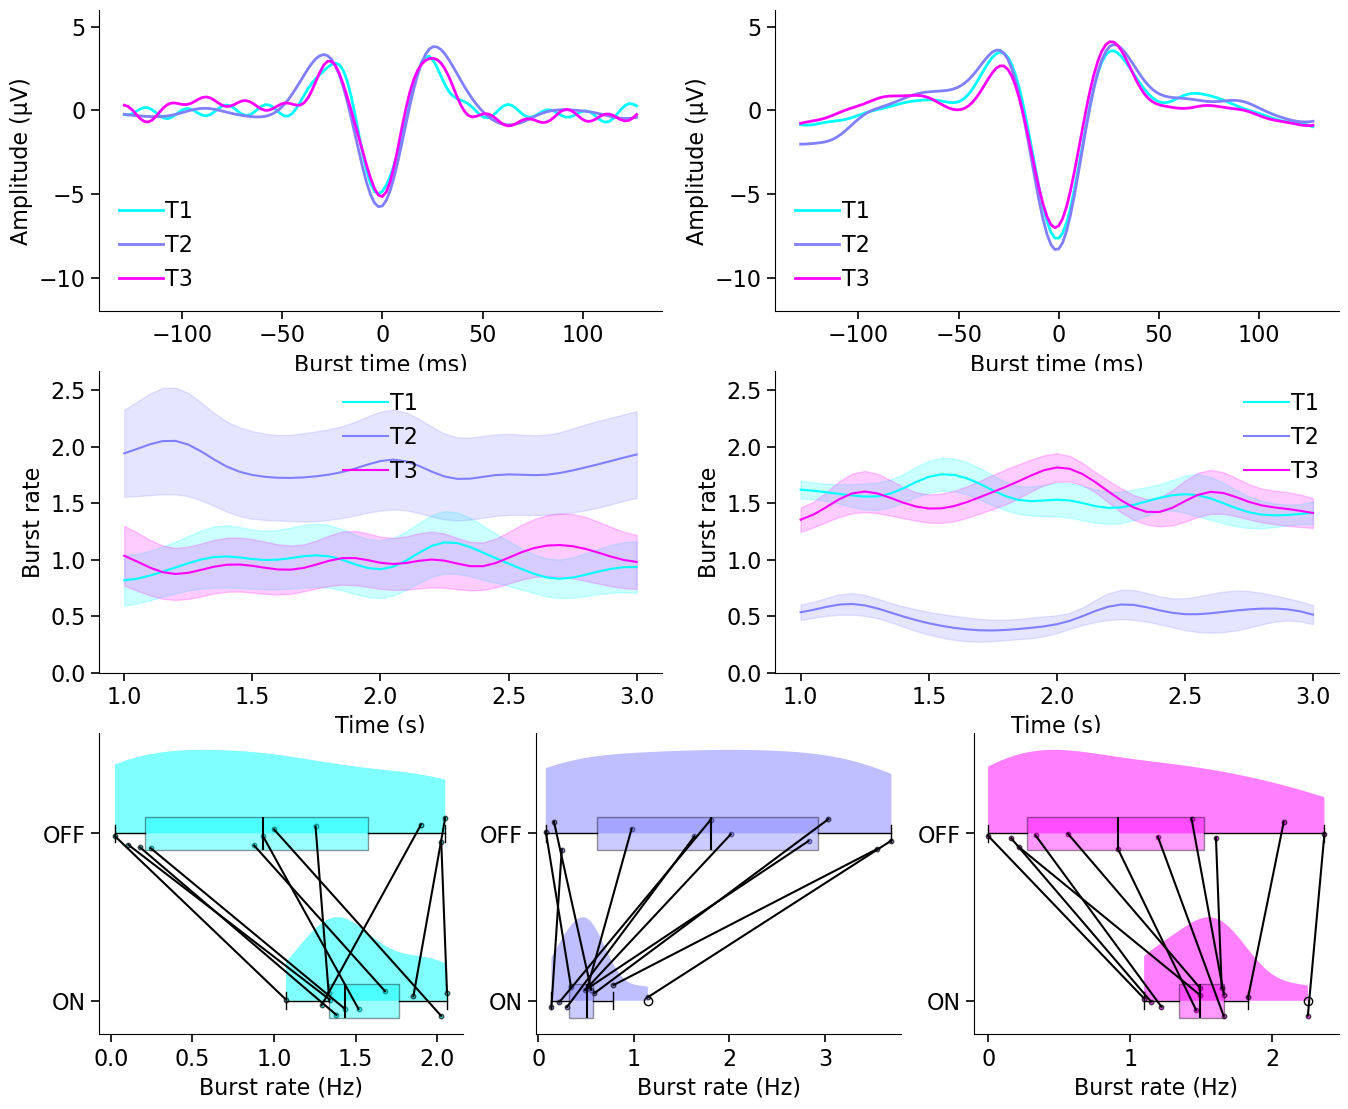

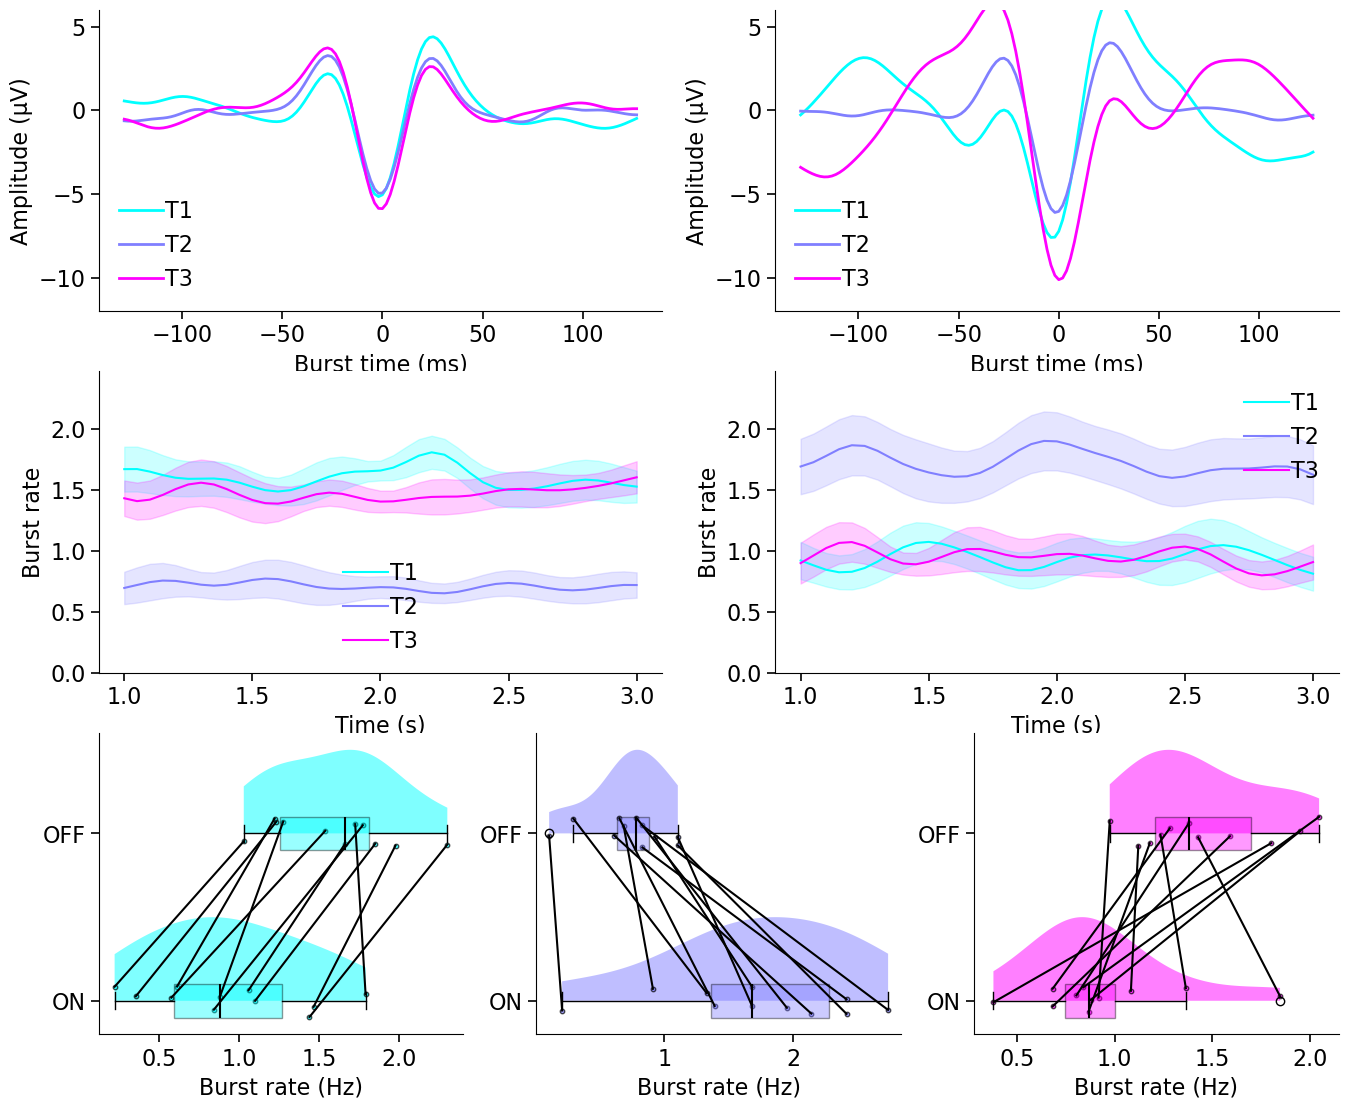

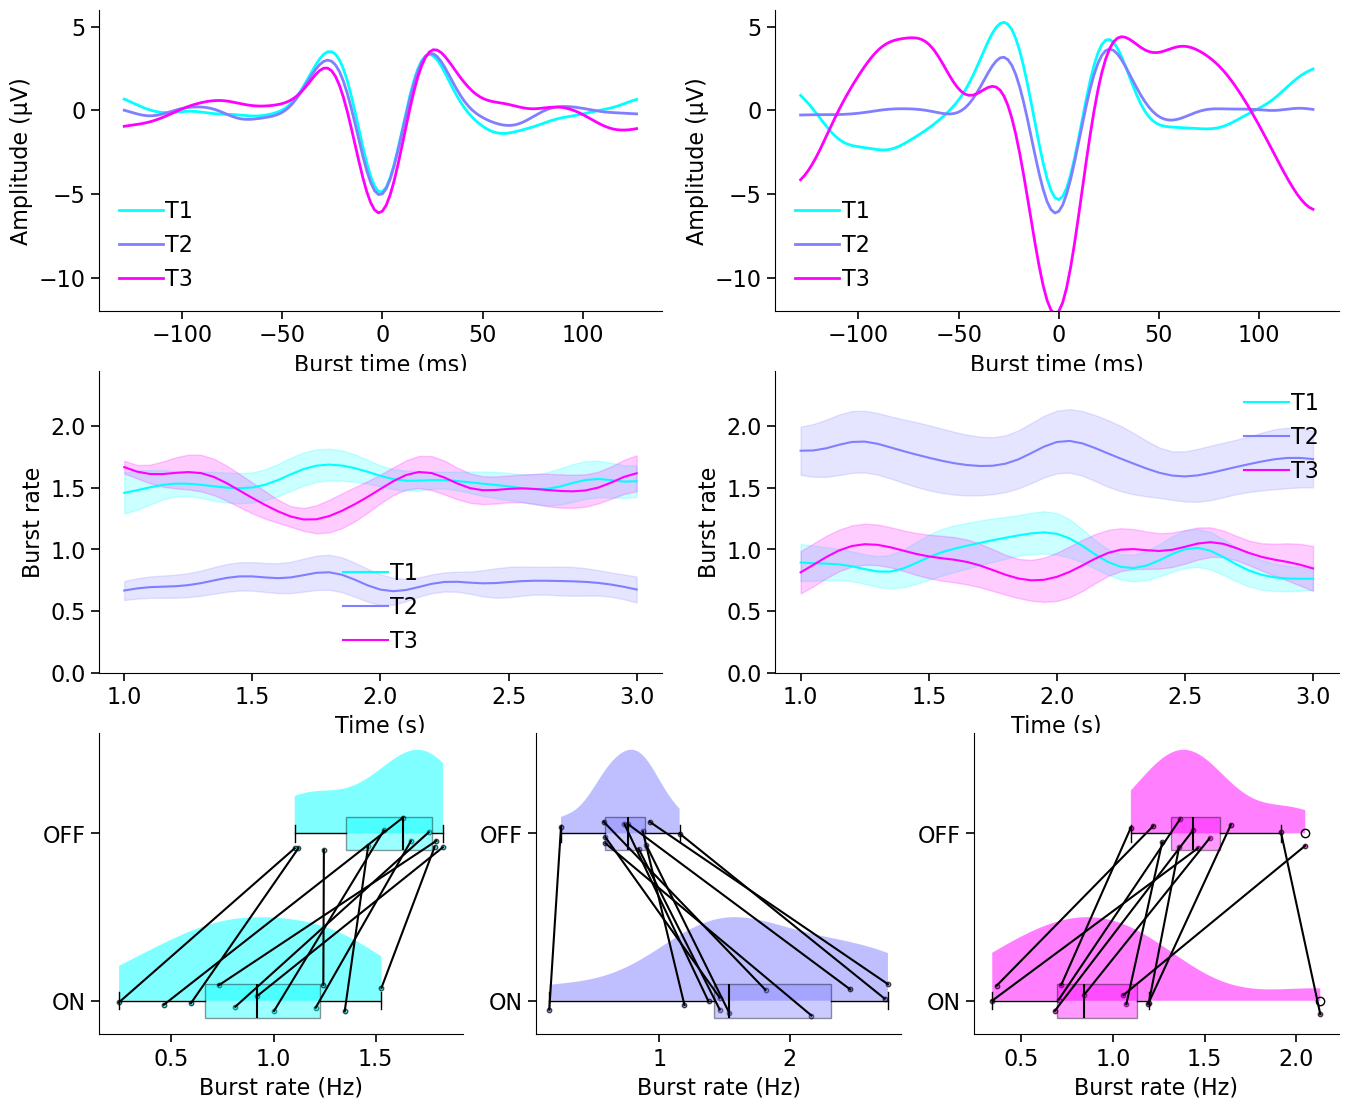

In [183]:
for pc_idx in [0,1,-2,-1]:
    plot_pc_burst_rate(pc_idx,c_idx)    

Radius T1: OFF: M=2.079, SD=1.490, ON: M=0.255, SD=0.221, p-value=0.022
Radius T2: OFF: M=0.585, SD=0.866, ON: M=1.959, SD=0.641, p-value=0.020
Radius T3: OFF: M=1.107, SD=1.812, ON: M=1.380, SD=1.083, p-value=1.000


/tmp/ipykernel_16129/3723651248.py:142: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


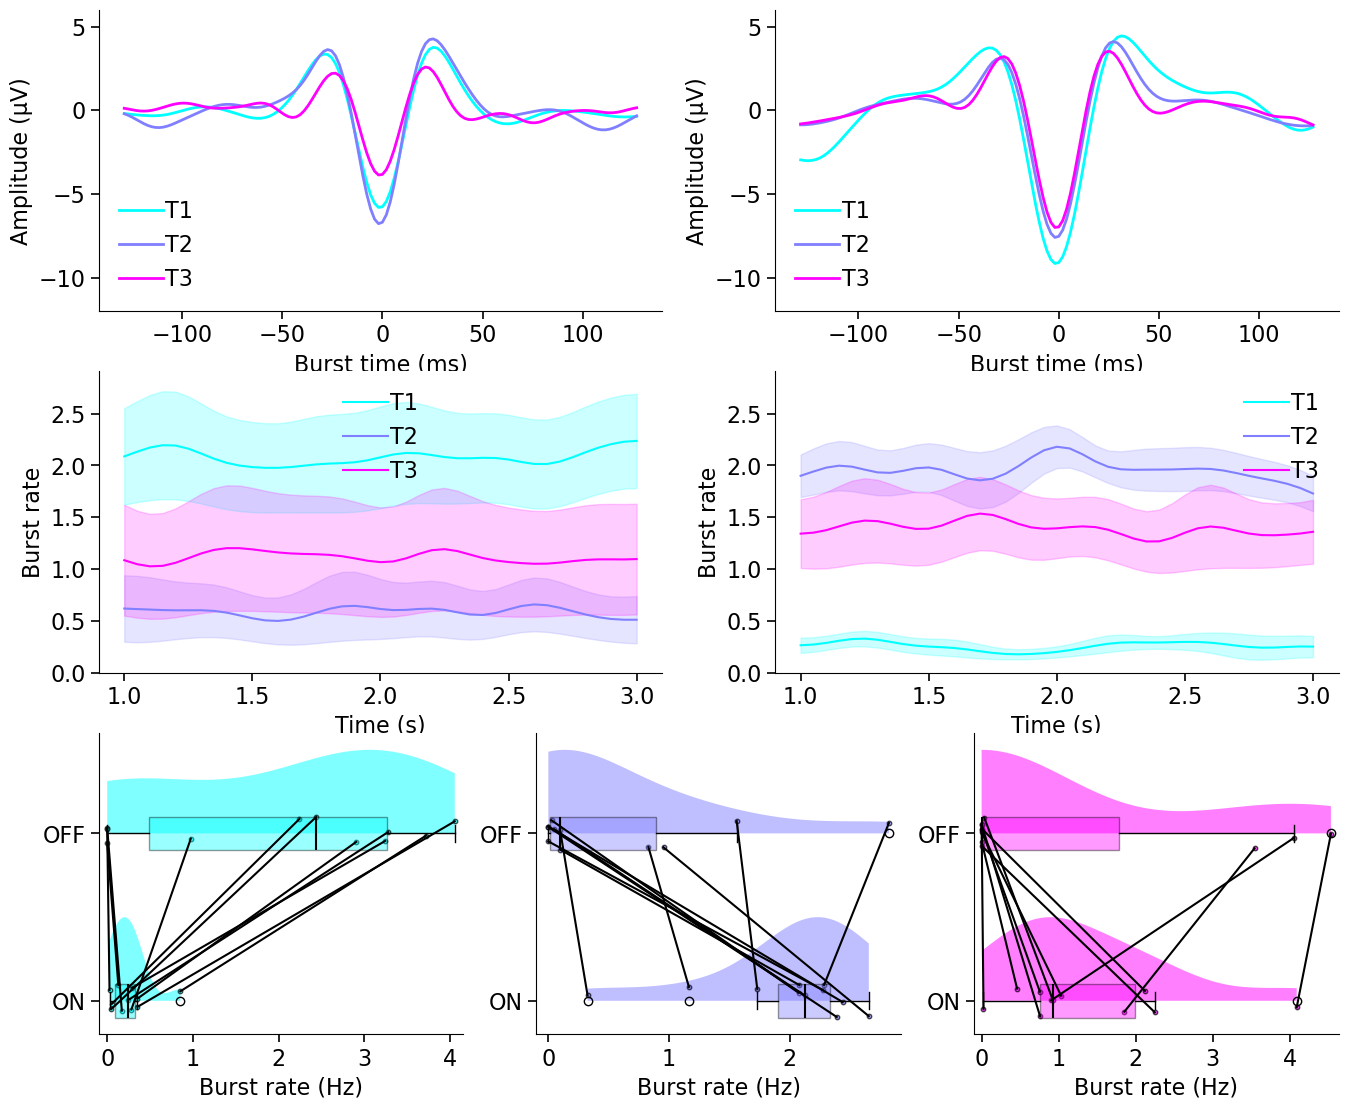

In [184]:
plot_radius_burst_rate(c_idx, 0, 1)

Radius T1: OFF: M=0.457, SD=0.294, ON: M=1.980, SD=0.896, p-value=0.007
Radius T2: OFF: M=1.284, SD=0.546, ON: M=1.157, SD=0.518, p-value=1.000
Radius T3: OFF: M=2.029, SD=0.811, ON: M=0.456, SD=0.973, p-value=0.003


/tmp/ipykernel_16129/3723651248.py:142: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


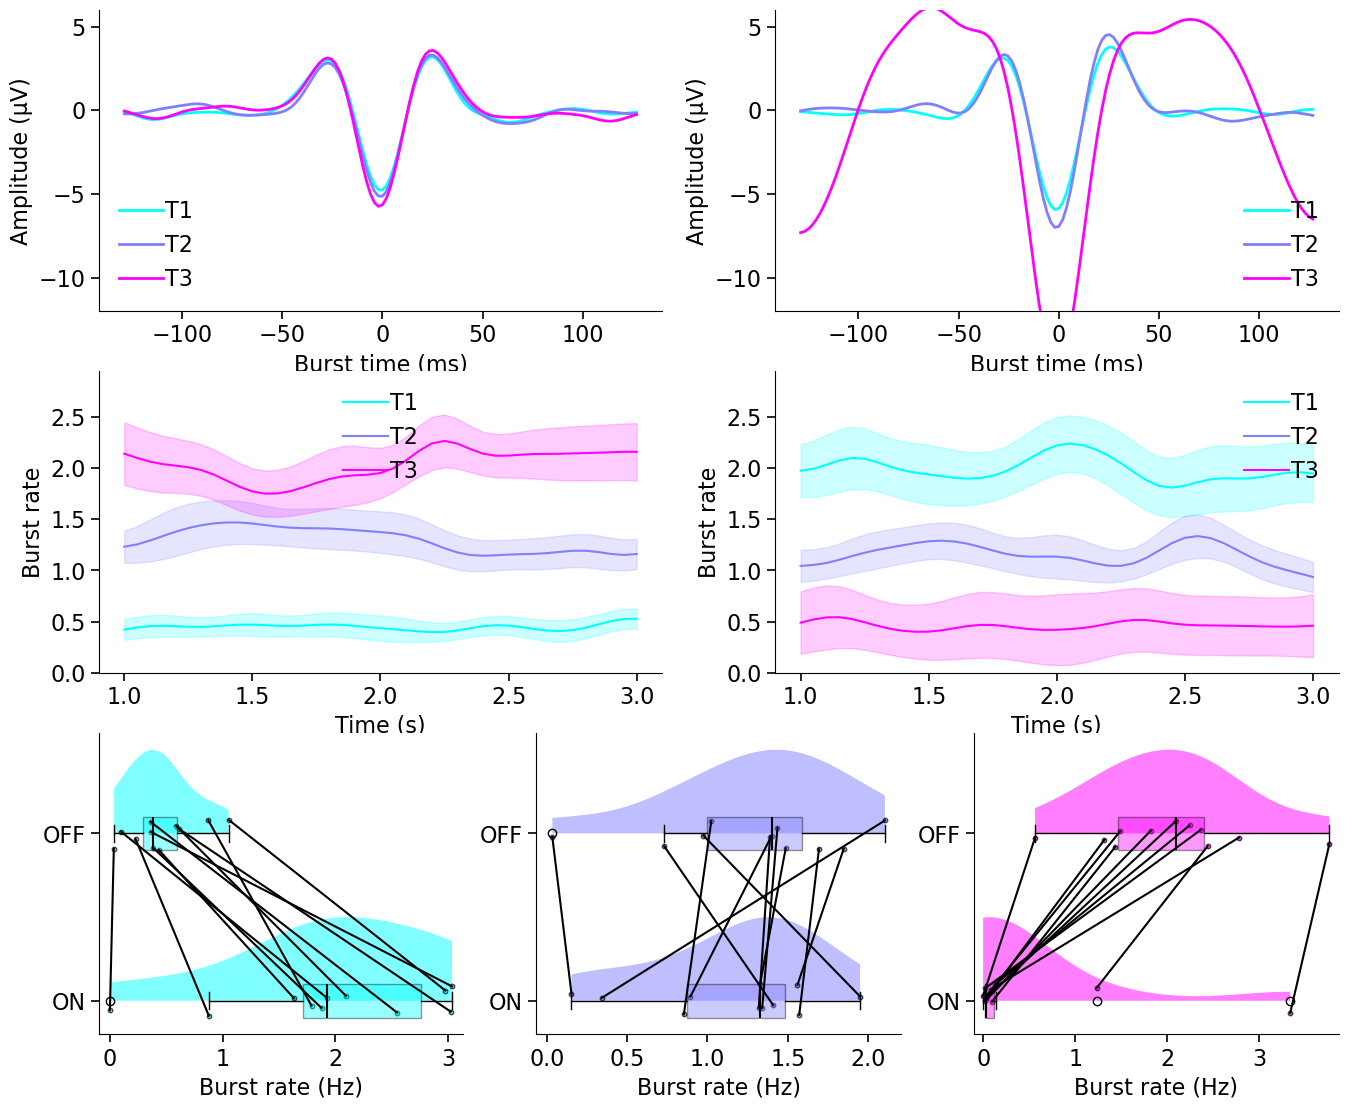

In [185]:
plot_radius_burst_rate(c_idx, -1, -2)

#### Plot PC1 for STN (significant p-value only for terile T2)

PC1 T1: OFF: M=0.980, SD=0.693,  ON: M=1.578, SD=0.350, p-value = 0.035
PC1 T2: OFF: M=1.934, SD=1.261,  ON: M=0.478, SD=0.177, p-value = 0.034
PC1 T3: OFF: M=0.949, SD=0.706,  ON: M=1.584, SD=0.264, p-value = 0.037


/tmp/ipykernel_16129/3723651248.py:287: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


PC2 T1: OFF: M=0.991, SD=0.719,  ON: M=1.579, SD=0.309, p-value = 0.035
PC2 T2: OFF: M=1.930, SD=1.226,  ON: M=0.495, SD=0.155, p-value = 0.030
PC2 T3: OFF: M=0.941, SD=0.646,  ON: M=1.565, SD=0.207, p-value = 0.040


/tmp/ipykernel_16129/3723651248.py:287: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


PC-1 T1: OFF: M=1.576, SD=0.296,  ON: M=0.958, SD=0.478, p-value = 0.006
PC-1 T2: OFF: M=0.731, SD=0.242,  ON: M=1.722, SD=0.664, p-value = 0.006
PC-1 T3: OFF: M=1.556, SD=0.234,  ON: M=0.959, SD=0.419, p-value = 0.003


/tmp/ipykernel_16129/3723651248.py:287: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


PC0 T1: OFF: M=1.620, SD=0.313,  ON: M=0.886, SD=0.344, p-value = 0.003
PC0 T2: OFF: M=0.703, SD=0.234,  ON: M=1.764, SD=0.612, p-value = 0.003
PC0 T3: OFF: M=1.539, SD=0.229,  ON: M=0.990, SD=0.468, p-value = 0.013


/tmp/ipykernel_16129/3723651248.py:287: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


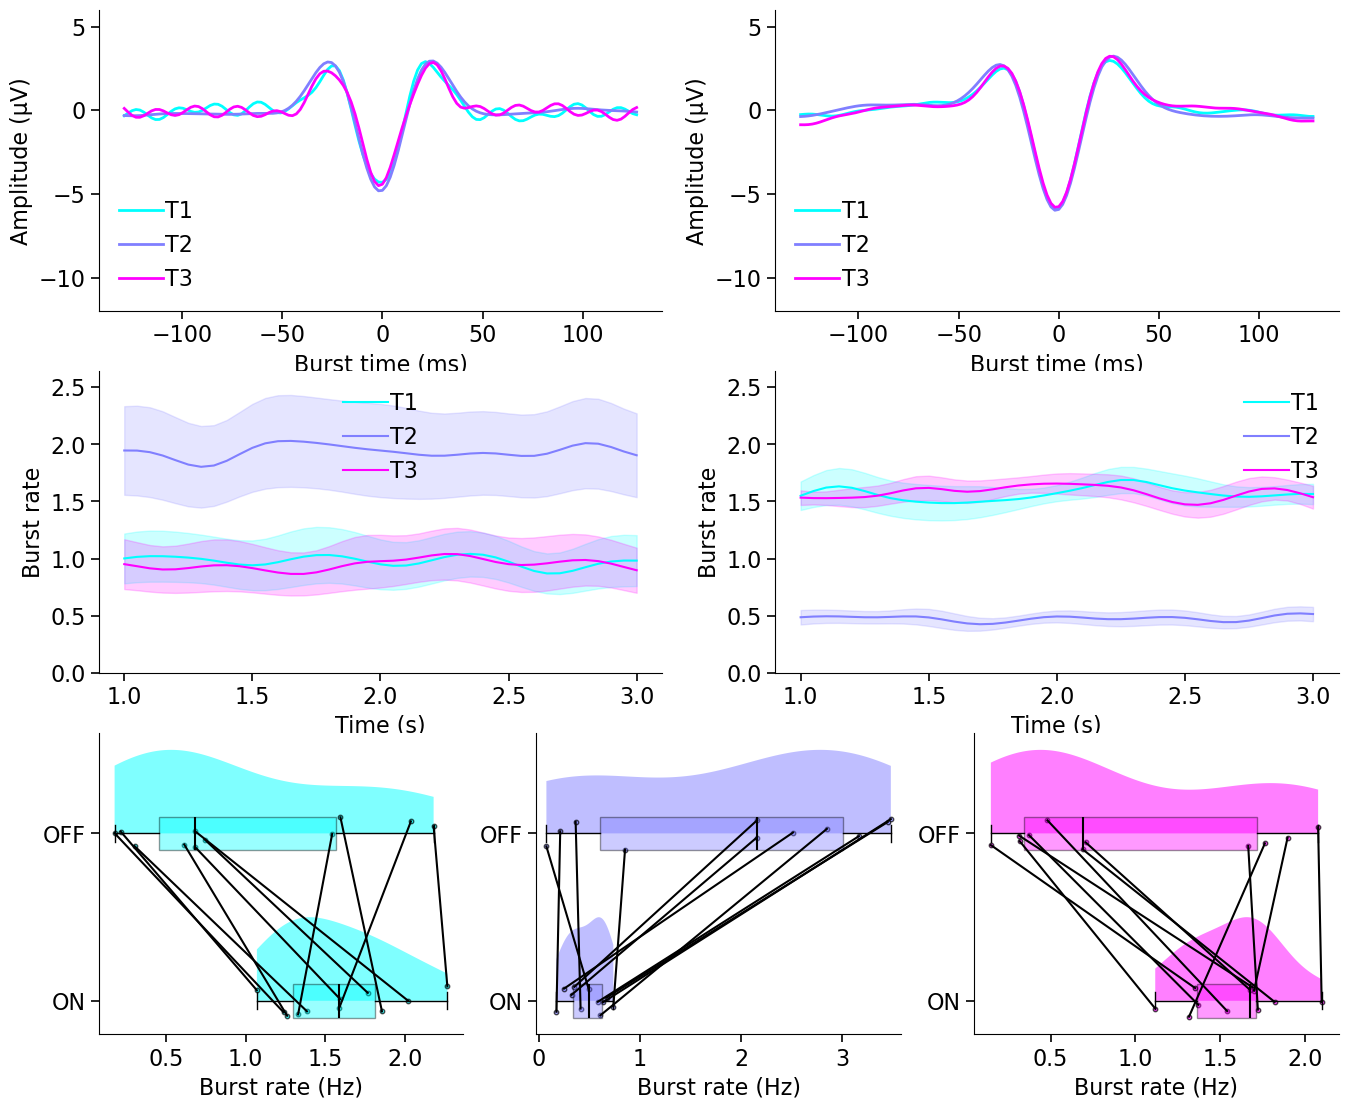

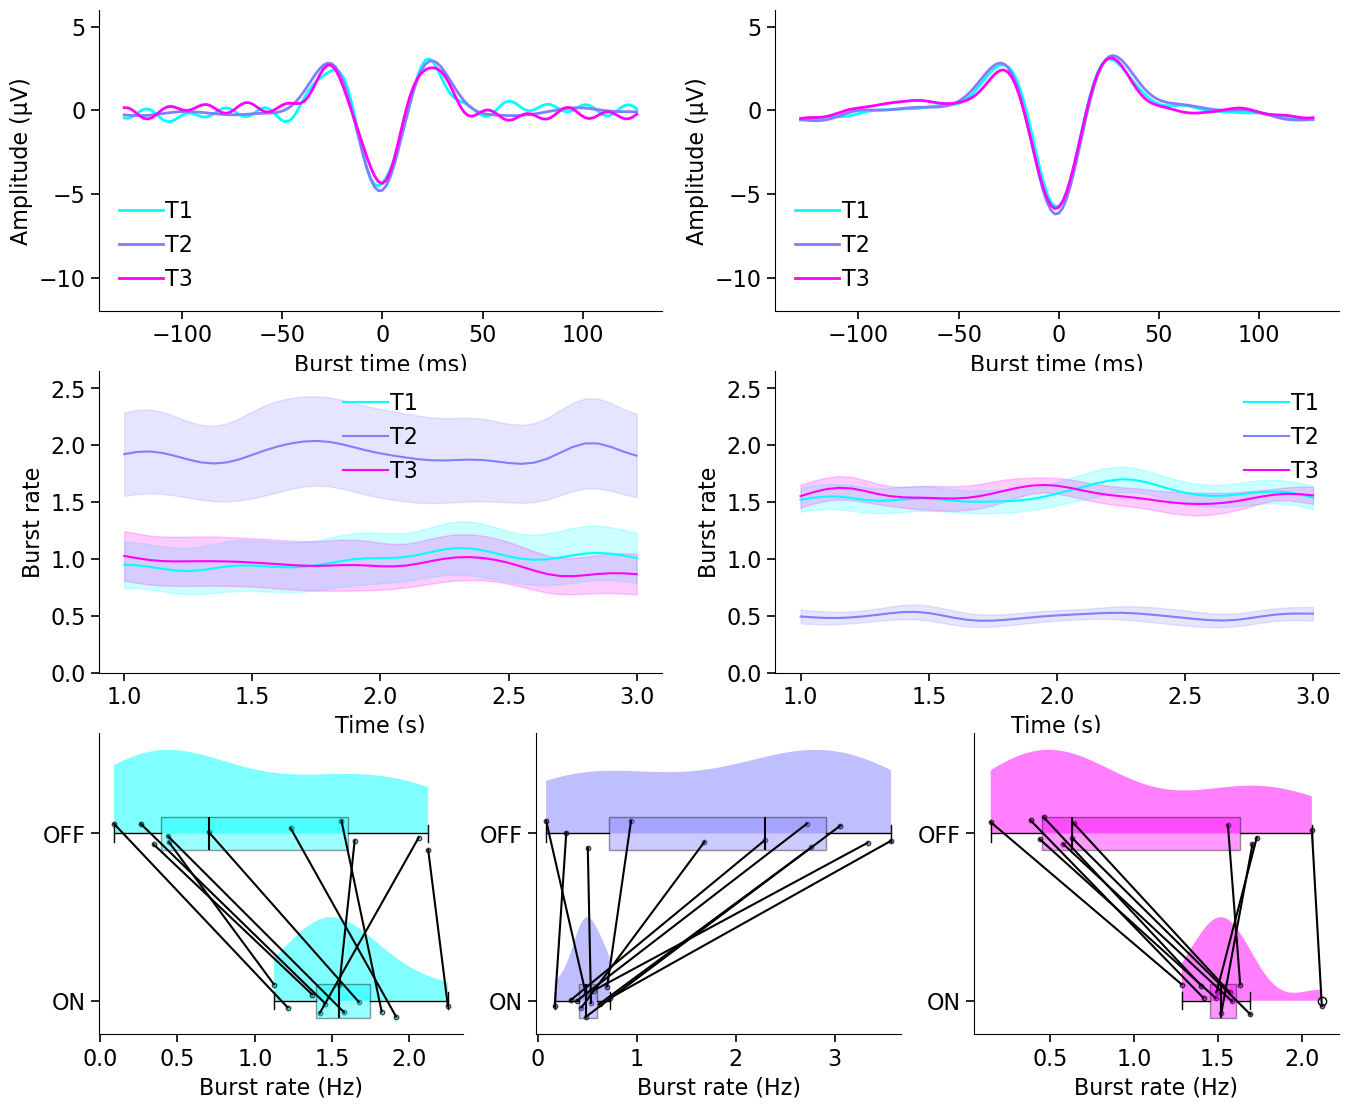

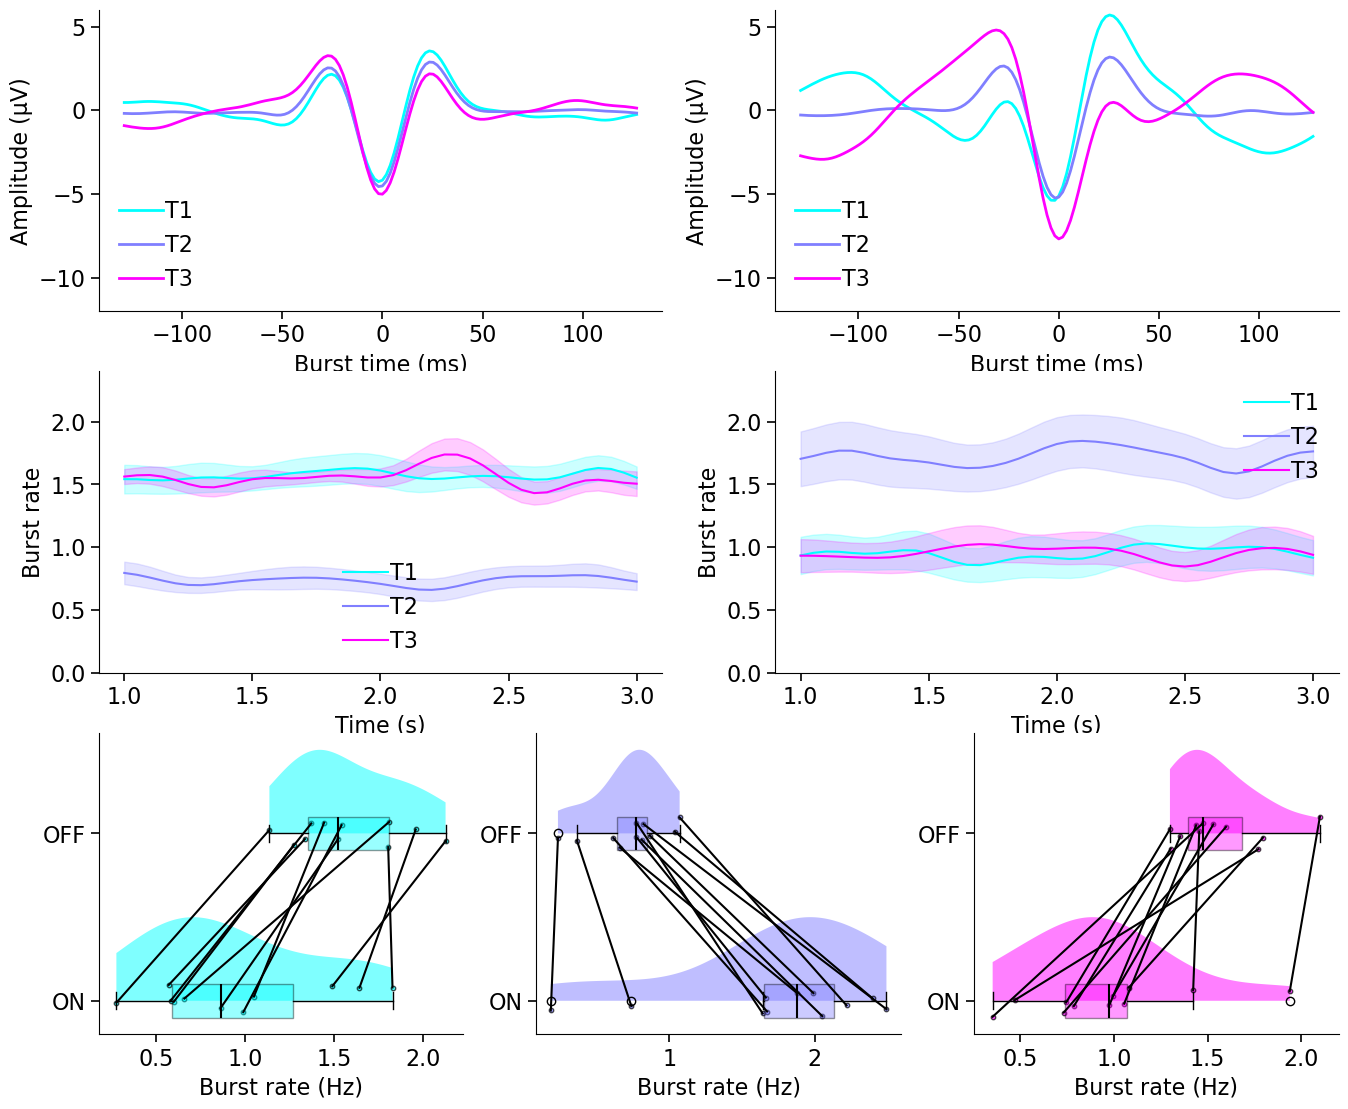

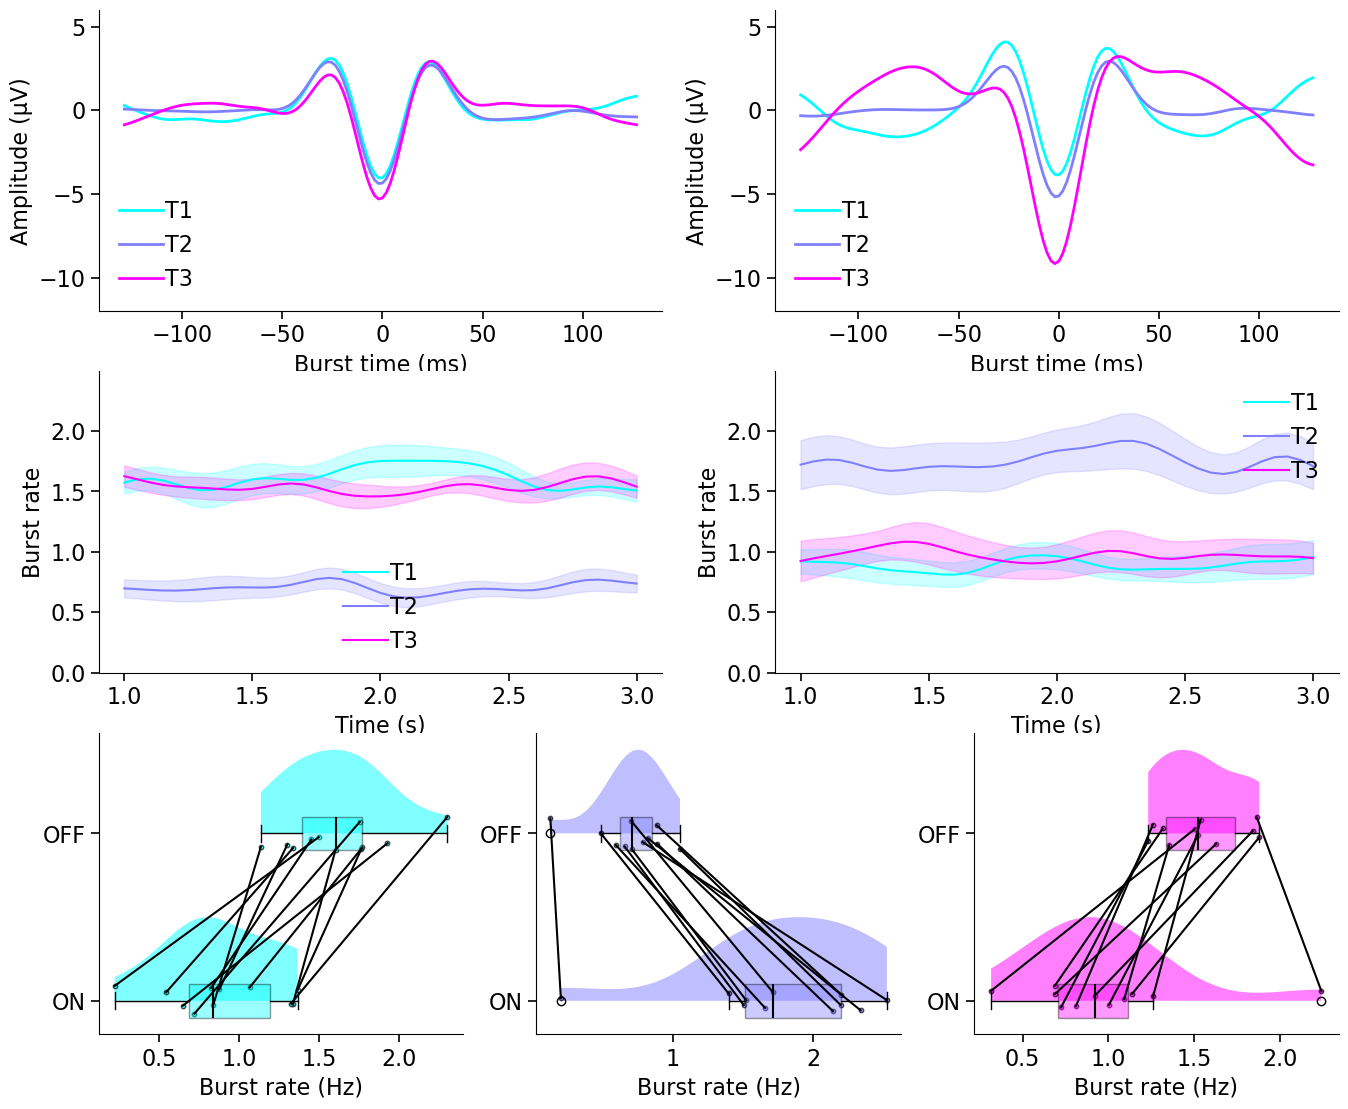

In [186]:
for pc_idx in [0,1,-2,-1]:
    plot_pc_burst_rate(pc_idx,stn_idx, n_electrodes=4)    

Radius T1: OFF: M=2.169, SD=1.564, ON: M=0.225, SD=0.141, p-value=0.029
Radius T2: OFF: M=0.752, SD=0.863, ON: M=1.817, SD=0.703, p-value=0.037
Radius T3: OFF: M=0.942, SD=1.488, ON: M=1.597, SD=1.113, p-value=0.393


/tmp/ipykernel_16129/3723651248.py:142: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


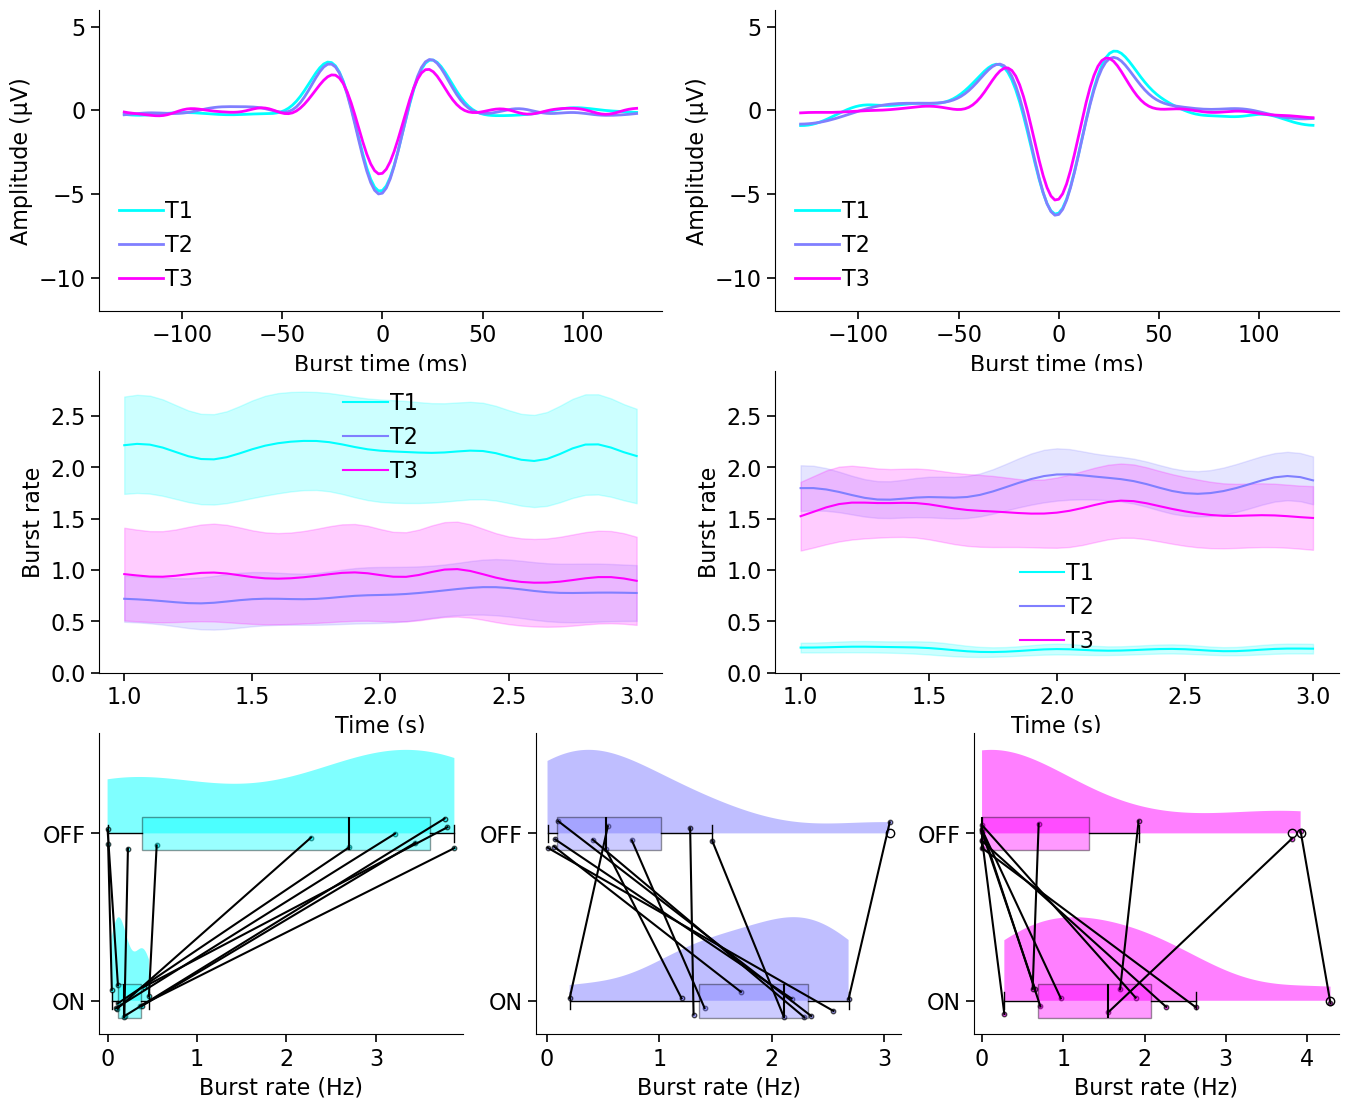

In [187]:
plot_radius_burst_rate(stn_idx, 0, 1, n_electrodes=4)

Radius T1: OFF: M=0.418, SD=0.193, ON: M=2.009, SD=0.819, p-value=0.003
Radius T2: OFF: M=1.353, SD=0.497, ON: M=1.142, SD=0.445, p-value=0.870
Radius T3: OFF: M=2.092, SD=0.783, ON: M=0.489, SD=1.035, p-value=0.003


/tmp/ipykernel_16129/3723651248.py:142: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


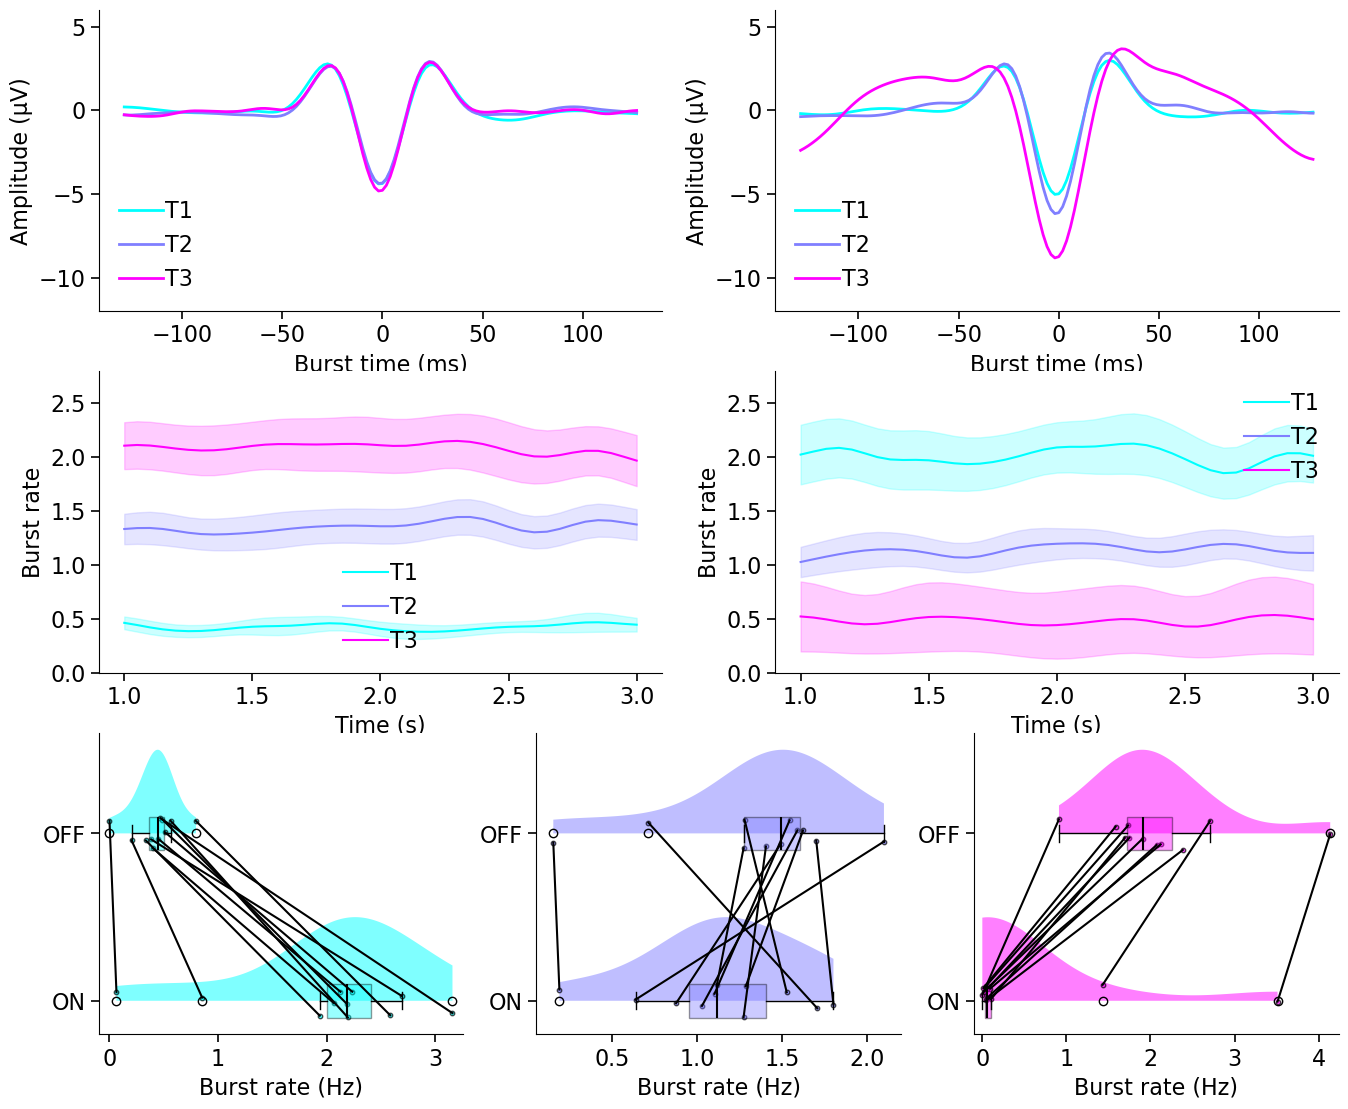

In [188]:
plot_radius_burst_rate(stn_idx, -1, -2, n_electrodes=4)

# Study the clinical correlation: Does levodopa-induced changes in waveform-specific burst rates correlate with clinical improvement ?

### Read clinical data

In [189]:
clinical_df=pd.read_csv('../PD_data_resting_state_med/final_versionfor_article_ clinical_data_selected_subjects_resting_state_PD - UPDRS_score.csv')

In [190]:
clinical_df=clinical_df.drop(index=np.where(clinical_df['UPDRS OFF']=='X')[0])

In [191]:
off_score=clinical_df['UPDRS OFF'].astype(float)
on_score=clinical_df['UPDRSIII ON'].astype(float)
clinical_df['clinical_score']=((off_score-on_score)/off_score)*100
clinical_df

,Patient,Age (years),Sex,Disease Duration (years),First symptom,Side onset,UPDRS OFF,UPDRSIII ON,Delay between surgery and recordings (days),Medication,clinical_score
0,S02,54,M,14,Tremor,R,27,5,3,ropinirole 8mg; l-dopa 1250mg/j ; entacapone ;...,81.481481
1,S04,69,F,12,AR,R,31,10,3,ropinirole 8mg; l-dopa 700mg/j ; entacapone,67.741935
2,S05,69,M,10,Tremor,R,32,5,3,piribedil 150mg/j ; l-dopa 1250mg/j ; entacapone,84.375000
3,S06,51,F,8,Tremor,L,40,16,3,NaN,60.000000
4,S07,55,F,10,AR,L,11,2,3,ropinirole 16mg ; l-dopa 400mg,81.818182
5,S08,65,F,12,AR,L,21,5,3,ropinirole 20mg; ldopa 725mg; entacapone; rasa...,76.190476
6,S10,59,M,17,AR,R,27,2,3,"pramipexole 2,10mg; ldopa 1200mg; entacapone",92.592593
8,S16,63,M,14,Tremor,L,29,9,3,"piribedil 150mg; ldopa 900mg, entacapone",68.965517
9,S17,64,M,7,Tremor,L,31,5,3,ropinirole 24mg; ldopa 800mg; entacapone; rasa...,83.870968
10,S18,56,F,8,Tremor,L,20,8,5,priribedil 150mg; ldopa 1000mg; entacapone,60.000000


### Study the clinical correlation using robust linear regression + compute confidence intervals and p-values through bootstrapping and permutation testing

**Study the clinical correlation using the Change in T1-((T2-T3)/2) rate (%)**

In [192]:
def regression(r_x_vals, r_y_vals):
    # Prepare the data for robust linear regression
    X = sm.add_constant(r_x_vals)  # Adding a constant for the intercept
    y = r_y_vals

    # Fit robust linear regression
    robust_model = RLM(y, X).fit()
    robust_slope, robust_intercept = robust_model.params[1], robust_model.params[0]

    # Generate the robust regression line
    x_vals = np.linspace(min(r_x_vals), max(r_x_vals), 100)
    robust_regression_line = robust_slope * x_vals + robust_intercept

    # Bootstrap for confidence intervals using robust linear regression
    n_bootstraps = 10000
    robust_bootstrapped_lines = []
    for _ in range(n_bootstraps):
        boot_x, boot_y = resample(r_x_vals, r_y_vals)
        boot_X = sm.add_constant(boot_x)
  
        try:
            boot_model = RLM(boot_y, boot_X).fit()
            robust_bootstrapped_lines.append(boot_model.params[1] * x_vals + boot_model.params[0])
        except (ValueError, np.linalg.LinAlgError):
            continue

    lower_bound = np.percentile(robust_bootstrapped_lines, 2.5, axis=0)
    upper_bound = np.percentile(robust_bootstrapped_lines, 97.5, axis=0)

    # Permutation test for the p-value of the robust regression slope
    n_permutations = 10000
    permuted_slopes = []

    for _ in range(n_permutations):
        permuted_y = np.random.permutation(r_y_vals)  # Permute the dependent variable
        try:
            permuted_model = RLM(permuted_y, X).fit()
            permuted_slopes.append(permuted_model.params[1])
        except (ValueError, np.linalg.LinAlgError):
            continue

    # Calculate p-value: proportion of permuted slopes as extreme as the observed slope
    p_value_permutation = np.mean(np.abs(permuted_slopes) >= np.abs(robust_slope))

    return robust_slope, p_value_permutation, x_vals, robust_regression_line, lower_bound, upper_bound
    
def relate_burst_clinical(subj_diffs, subj_scores, on_diffs, off_diffs, exp):
    oo_slope, oo_p, oo_xvals, oo_line, oo_lower, oo_upper = regression(off_diffs, on_diffs)
    print(f'ON/OFF: coefficient={oo_slope}, p={oo_p}')
    ci_slope, ci_p, ci_xvals, ci_line, ci_lower, ci_upper = regression(subj_diffs, subj_scores)
    print(f'Clinical improvement: coefficient={ci_slope}, p={ci_p}')

    #if ci_p<0.05:
    # Plot
    plt.figure(figsize=(16, 6))
    plt.rcParams.update({
        'font.size': 14,
        'axes.spines.right': False,
        'axes.spines.top': False,
        'xtick.major.size': 6,
        'xtick.major.width': 1.2,
        'ytick.major.size': 6,
        'ytick.major.width': 1.2,
        'legend.frameon': False,
        'legend.handletextpad': 0.1,
        'svg.fonttype': 'none',
        'text.usetex': False
    })
    ax1=plt.subplot(1,2,1)
    plt.scatter(off_diffs, on_diffs, color='k', s=50)
    plt.plot([0.5,2],[0.5,2],'k--')
    plt.plot(oo_xvals, oo_line, 'b-', label='Robust Regression Line')
    plt.fill_between(oo_xvals, oo_lower, oo_upper, color='blue', alpha=0.2, label='95% Confidence Interval')
    plt.xlabel(f'OFF: {exp} rate (Hz)')
    plt.ylabel(f'ON: {exp} rate (Hz)')
    
    ax2=plt.subplot(1,2,2)
    plt.scatter(subj_diffs, subj_scores, label='Data Points', color='k', s=50)
    plt.plot(ci_xvals, ci_line, 'b-', label='Robust Regression Line')
    plt.fill_between(ci_xvals, ci_lower, ci_upper, color='blue', alpha=0.2, label='95% Confidence Interval')
    plt.xlabel(f'Change in {exp} rate (Hz)')
    plt.ylabel('Clinical improvement (%)')
    plt.tight_layout()
    

In [193]:
def run_radius_clinical_score_corr(b_idx, pc_idx1, pc_idx2, exp):
    subjects = np.unique(all_bursts['subject'])
    trial_dur = 4
    time_bin_size = .05
    time_bins = np.arange(0, trial_dur + time_bin_size, time_bin_size)
    idx = np.where((time_bins >= 1) & (time_bins <= (trial_dur - 1)))[0]
    # Compute radius once
    radius = np.sqrt(all_scores[:, pc_idx1]**2 + all_scores[:, pc_idx2]**2)
    
    n_q = 3  # number of radial bins
    step = 100 / n_q
    q_bins = np.percentile(radius[b_idx], np.arange(0, 100 + step, step))
            
    subj_scores = []
    subj_diffs = []
    on_diffs = []
    off_diffs = []
    
    for subject in subjects:
        subj_idx = b_idx & (all_bursts['subject'] == subject)
    
        if subject.upper() in clinical_df['Patient'].values:
            subj_clinical_score = clinical_df['clinical_score'][clinical_df['Patient'] == subject.upper()].values[0]
    
            # Select bursts **inside the current radius bin**
            radial_mask = (radius >= q_bins[0]) & (radius <= q_bins[1])
    
            med = 'ON'
            med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med'] == med)])
            q0_on_unsmoothed_rate, _ = np.histogram(all_bursts['peak_time'][subj_idx & (all_bursts['med'] == med) & radial_mask], bins=time_bins)
            q0_on_unsmoothed_rate = (q0_on_unsmoothed_rate / time_bin_size) / len(med_trials)
    
            med = 'OFF'
            med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med'] == med)])
            q0_off_unsmoothed_rate, _ = np.histogram(all_bursts['peak_time'][subj_idx & (all_bursts['med'] == med) & radial_mask], bins=time_bins)
            q0_off_unsmoothed_rate = (q0_off_unsmoothed_rate / time_bin_size) / len(med_trials)
    
            # Select bursts **inside the current radius bin**
            radial_mask = (radius >= q_bins[1]) & (radius <= q_bins[2])
    
            med = 'ON'
            med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med'] == med)])
            q1_on_unsmoothed_rate, _ = np.histogram(all_bursts['peak_time'][subj_idx & (all_bursts['med'] == med) & radial_mask], bins=time_bins)
            q1_on_unsmoothed_rate = (q1_on_unsmoothed_rate / time_bin_size) / len(med_trials)
    
            med = 'OFF'
            med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med'] == med)])
            q1_off_unsmoothed_rate, _ = np.histogram(all_bursts['peak_time'][subj_idx & (all_bursts['med'] == med) & radial_mask], bins=time_bins)
            q1_off_unsmoothed_rate = (q1_off_unsmoothed_rate / time_bin_size) / len(med_trials)

            if len(q_bins)>3:
                # Select bursts **inside the current radius bin**
                radial_mask = (radius >= q_bins[2]) & (radius <= q_bins[3])
        
                med = 'ON'
                med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med'] == med)])
                q2_on_unsmoothed_rate, _ = np.histogram(all_bursts['peak_time'][subj_idx & (all_bursts['med'] == med) & radial_mask], bins=time_bins)
                q2_on_unsmoothed_rate = (q2_on_unsmoothed_rate / time_bin_size) / len(med_trials)
        
                med = 'OFF'
                med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med'] == med)])
                q2_off_unsmoothed_rate, _ = np.histogram(all_bursts['peak_time'][subj_idx & (all_bursts['med'] == med) & radial_mask], bins=time_bins)
                q2_off_unsmoothed_rate = (q2_off_unsmoothed_rate / time_bin_size) / len(med_trials)

            if exp=='T1-T2':
                on_diff = np.mean(q0_on_unsmoothed_rate[idx])-np.mean(q1_on_unsmoothed_rate[idx])
                off_diff = np.mean(q0_off_unsmoothed_rate[idx])-np.mean(q1_off_unsmoothed_rate[idx])
            elif exp=='T1-T3':
                on_diff = np.mean(q0_on_unsmoothed_rate[idx])-np.mean(q2_on_unsmoothed_rate[idx])
                off_diff = np.mean(q0_off_unsmoothed_rate[idx])-np.mean(q2_off_unsmoothed_rate[idx])
            elif exp=='0-m12':
                on_diff = np.mean(q0_on_unsmoothed_rate[idx])-(np.mean([np.mean(q1_on_unsmoothed_rate[idx]),np.mean(q2_on_unsmoothed_rate[idx])]))
                off_diff = np.mean(q0_off_unsmoothed_rate[idx])-(np.mean([np.mean(q1_off_unsmoothed_rate[idx]),np.mean(q2_off_unsmoothed_rate[idx])]))
    
            on_diffs.append(on_diff)
            off_diffs.append(off_diff)
    
            diff_diff = ((on_diff - off_diff))# / off_diff) * 100
            subj_scores.append(subj_clinical_score)
            subj_diffs.append(diff_diff)
    
    # Correlate burst change with clinical score
    relate_burst_clinical(subj_diffs, subj_scores, on_diffs, off_diffs, exp)
    
    spearman_coefficient, spearman_p_value = spearmanr(subj_diffs, subj_scores)
    print(f"Spearman Correlation: r={spearman_coefficient:.2f}, p={spearman_p_value:.3f}")


### For sensorimotor cortex

/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisso

ON/OFF: coefficient=0.042373216942371145, p=0.4843


/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisso

Clinical improvement: coefficient=-4.227145806219396, p=0.036
Spearman Correlation: r=-0.64, p=0.047


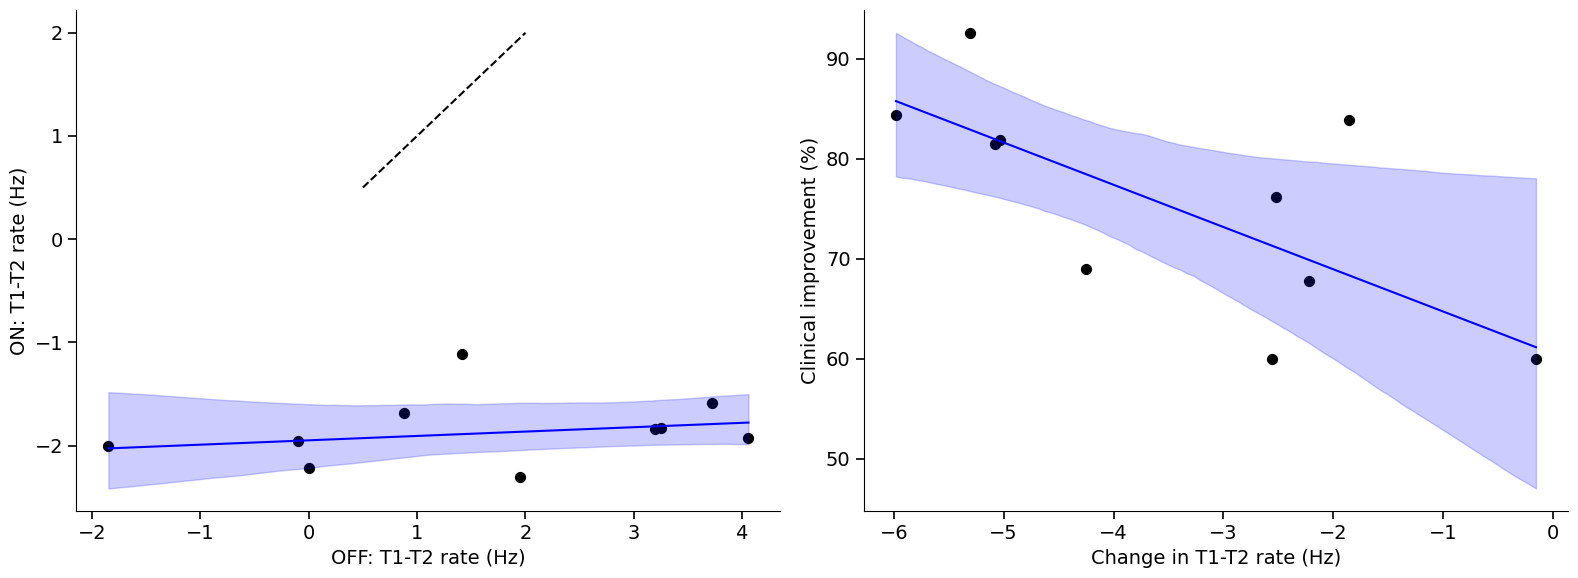

In [194]:
run_radius_clinical_score_corr(c_idx, 0, 1, 'T1-T2')

/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisso

ON/OFF: coefficient=1.25917038804783, p=0.0129


/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisso

Clinical improvement: coefficient=-5.311053492659841, p=0.0797
Spearman Correlation: r=-0.41, p=0.235


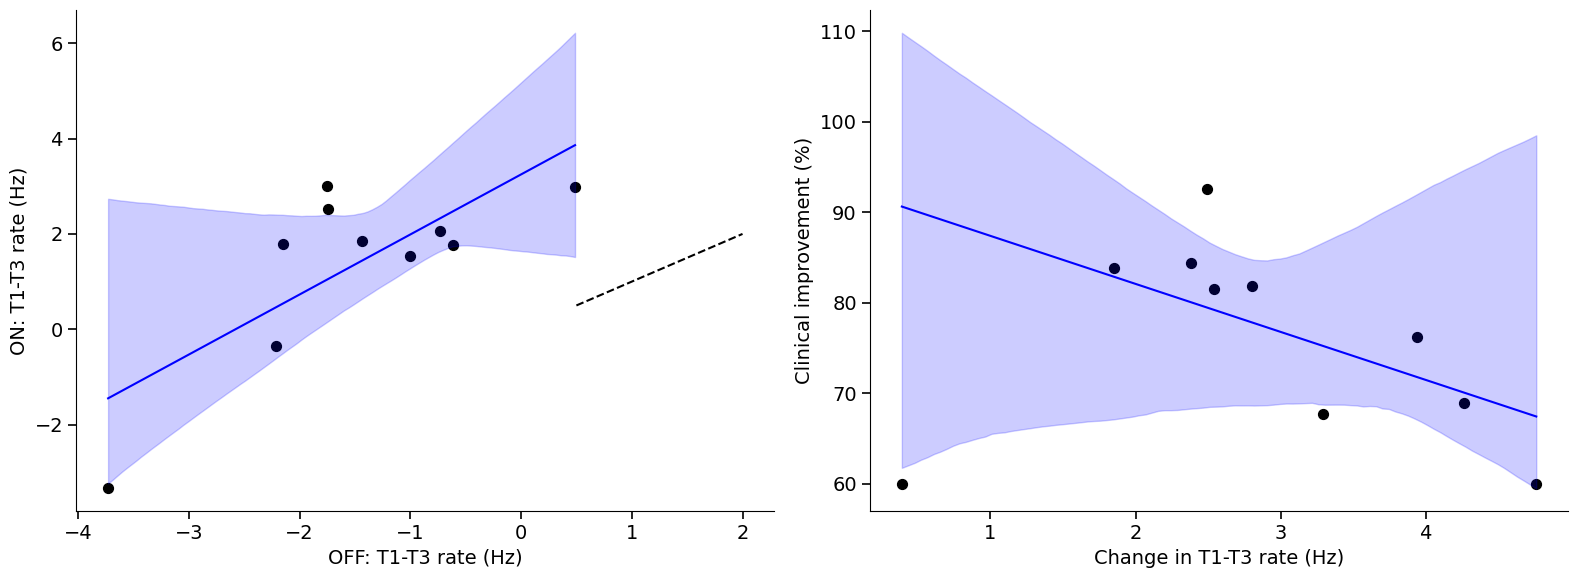

In [196]:
run_radius_clinical_score_corr(c_idx, -1, -2, 'T1-T3')

### For STN

/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisso

ON/OFF: coefficient=0.013446878012151442, p=0.8408


/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisso

Clinical improvement: coefficient=-0.9373624227051622, p=0.0206
Spearman Correlation: r=-0.66, p=0.039


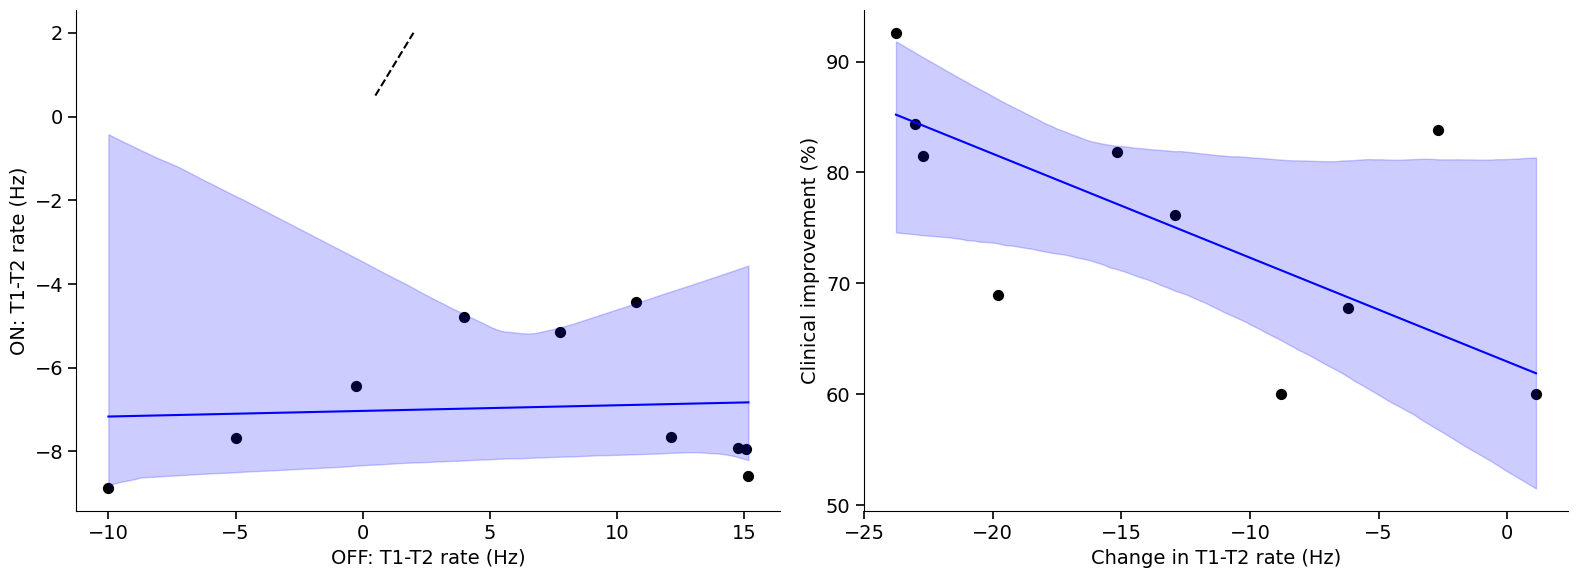

In [197]:
run_radius_clinical_score_corr(stn_idx, 0, 1,'T1-T2')

/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisso

ON/OFF: coefficient=1.8726455411211371, p=0.0005


/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisson_glm_granger/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/home/bonaiuto/miniconda3/envs/poisso

Clinical improvement: coefficient=0.13630006094463631, p=0.906
Spearman Correlation: r=-0.24, p=0.498


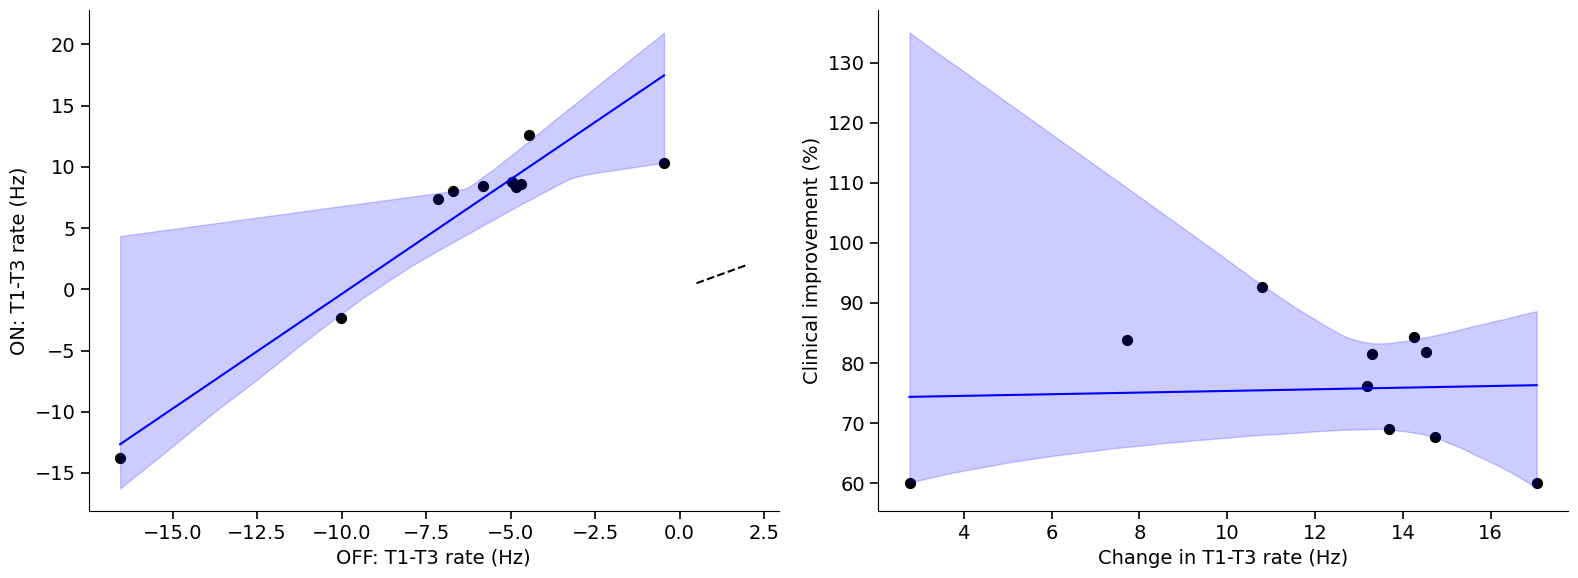

In [198]:
run_radius_clinical_score_corr(stn_idx, -1, -2, 'T1-T3')

### Correlation with other burst features 

In [42]:
subjects = np.unique(all_bursts['subject'])
    
subj_scores=[]
subj_diffs=[]

for subject in subjects:
    if subject.upper() in clinical_df['Patient'].values:
        subj_clinical_score = clinical_df['clinical_score'][clinical_df['Patient']==subject.upper()].values[0]

        on_brst_idx=stn_idx & (all_bursts['subject']==subject) & (all_bursts['med']=='ON')
        off_brst_idx=stn_idx & (all_bursts['subject']==subject) & (all_bursts['med']=='OFF')

        # Calculate medians and IQRs
        on_data = np.mean(all_bursts['fwhm_time'][on_brst_idx])
        off_data = np.mean(all_bursts['fwhm_time'][off_brst_idx])
        
        on_off_diff=((on_data-off_data)/off_data)*100
        subj_scores.append(subj_clinical_score)
        subj_diffs.append(on_off_diff)
slope, p, _, _, _, _ = regression(subj_diffs, subj_scores)
print(f'coefficient={slope}, p={p}')

C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib

coefficient=0.16073784965853744, p=0.7171


In [43]:
subjects = np.unique(all_bursts['subject'])
    
subj_scores=[]
subj_diffs=[]

for subject in subjects:
    if subject.upper() in clinical_df['Patient'].values:
        subj_clinical_score = clinical_df['clinical_score'][clinical_df['Patient']==subject.upper()].values[0]

        on_brst_idx=stn_idx & (all_bursts['subject']==subject) & (all_bursts['med']=='ON')
        off_brst_idx=stn_idx & (all_bursts['subject']==subject) & (all_bursts['med']=='OFF')

        # Calculate medians and IQRs
        on_data = np.mean(all_bursts['peak_amp_base'][on_brst_idx])
        off_data = np.mean(all_bursts['peak_amp_base'][off_brst_idx])
        
        on_off_diff=((on_data-off_data)/off_data)*100
        subj_scores.append(subj_clinical_score)
        subj_diffs.append(on_off_diff)
slope, p, _, _, _, _ = regression(subj_diffs, subj_scores)
print(f'coefficient={slope}, p={p}')

C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib

coefficient=-0.09397447973777395, p=0.5564


In [44]:
subjects = np.unique(all_bursts['subject'])
    
subj_scores=[]
subj_diffs=[]

for subject in subjects:
    if subject.upper() in clinical_df['Patient'].values:
        subj_clinical_score = clinical_df['clinical_score'][clinical_df['Patient']==subject.upper()].values[0]

        on_brst_idx=stn_idx & (all_bursts['subject']==subject) & (all_bursts['med']=='ON')
        off_brst_idx=stn_idx & (all_bursts['subject']==subject) & (all_bursts['med']=='OFF')

        # Calculate medians and IQRs
        on_data = np.mean(all_bursts['peak_freq'][on_brst_idx])
        off_data = np.mean(all_bursts['peak_freq'][off_brst_idx])
        
        on_off_diff=((on_data-off_data)/off_data)*100
        subj_scores.append(subj_clinical_score)
        subj_diffs.append(on_off_diff)
slope, p, _, _, _, _ = regression(subj_diffs, subj_scores)
print(f'coefficient={slope}, p={p}')

C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib

coefficient=-0.13888677885552858, p=0.8031


In [45]:
subjects = np.unique(all_bursts['subject'])
    
subj_scores=[]
subj_diffs=[]

for subject in subjects:
    if subject.upper() in clinical_df['Patient'].values:
        subj_clinical_score = clinical_df['clinical_score'][clinical_df['Patient']==subject.upper()].values[0]

        on_brst_idx=stn_idx & (all_bursts['subject']==subject) & (all_bursts['med']=='ON')
        off_brst_idx=stn_idx & (all_bursts['subject']==subject) & (all_bursts['med']=='OFF')

        # Calculate medians and IQRs
        on_data = np.mean(all_bursts['fwhm_freq'][on_brst_idx])
        off_data = np.mean(all_bursts['fwhm_freq'][off_brst_idx])
        
        on_off_diff=((on_data-off_data)/off_data)*100
        subj_scores.append(subj_clinical_score)
        subj_diffs.append(on_off_diff)
slope, p, _, _, _, _ = regression(subj_diffs, subj_scores)
print(f'coefficient={slope}, p={p}')

C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib

coefficient=0.12612641201791064, p=0.8739


In [46]:
subjects = np.unique(all_bursts['subject'])
trial_dur=4
    
time_bin_size = .05
time_bins = np.arange(0, trial_dur + time_bin_size, time_bin_size)
idx = np.where((time_bins >= 1) & (time_bins <= (trial_dur - 1)))[0]
    
subj_scores=[]
subj_diffs=[]

for subject in subjects:
    subj_idx = stn_idx & (all_bursts['subject'] == subject)
    if subject.upper() in clinical_df['Patient'].values:
        subj_clinical_score = clinical_df['clinical_score'][clinical_df['Patient']==subject.upper()].values[0]

        med='ON'
        med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med']==med)])
        on_unsmoothed_rate, _ = np.histogram(all_bursts['peak_time'][subj_idx & (all_bursts['med'] == med)], bins=time_bins)
        on_unsmoothed_rate = (on_unsmoothed_rate / time_bin_size) / len(med_trials)

        med='OFF'
        med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med']==med)])
        off_unsmoothed_rate, _ = np.histogram(all_bursts['peak_time'][subj_idx & (all_bursts['med'] == med)], bins=time_bins)
        off_unsmoothed_rate = (off_unsmoothed_rate / time_bin_size) / len(med_trials)

        on_rate=np.mean(on_unsmoothed_rate[idx])
        off_rate=np.mean(off_unsmoothed_rate[idx])

        on_off_diff=((on_rate-off_rate)/off_rate)*100
        subj_scores.append(subj_clinical_score)
        subj_diffs.append(on_off_diff)
slope, p, _, _, _, _ = regression(subj_diffs, subj_scores)
print(f'coefficient={slope}, p={p}')

C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\ppsor\AppData\Local\Programs\Python\Python313\Lib

coefficient=-0.171689815051838, p=0.7159
